In [1]:
# ---[ 1. Setup ]---
!pip install torch numpy scipy matplotlib

import numpy as np
import torch, matplotlib.pyplot as plt
from scipy import stats
import warnings, time

# ---[ 2. Paste the full URT code here ]---
# ⚠️ Paste all your classes from UniversalRecursiveTuning up through EnhancedURTBenchmark.
# (You can collapse the long code cells in Colab for clarity.)
# Example:
# from your provided snippet, paste:
# UniversalRecursiveTuning
# AdaptiveURT
# VectorizedMultiScaleURT
# NeuralURTEnhanced
# EnhancedConstrainedURT
# EnhancedHybridURT
# EnhancedPerformanceURT
# EnhancedRobustURT
# EnhancedURTBenchmark
# ---[ End of pasted URT definitions ]---


# ---[ 3. Minimal validation experiment ]---

# Create small instances to test functionality
base = UniversalRecursiveTuning(state_dim=10)
adaptive = AdaptiveURT(state_dim=10)
vectorized = VectorizedMultiScaleURT(n_scales=2, state_dim=10)
neural = NeuralURTEnhanced(state_dim=10)
constrained = EnhancedConstrainedURT(state_dim=10)
robust = EnhancedRobustURT(state_dim=10)

# Register frameworks for benchmarking
bench = EnhancedURTBenchmark(n_trials=5)
bench.register_framework("BaseURT", base, "Baseline contraction mapping")
bench.register_framework("AdaptiveURT", adaptive, "Adaptive beta control")
bench.register_framework("VectorizedURT", vectorized, "Multi-scale vectorized URT")
bench.register_framework("NeuralURT", neural, "Neural correction URT")
bench.register_framework("ConstrainedURT", constrained, "Constraint handling")
bench.register_framework("RobustURT", robust, "Noise/disturbance rejection")

# ---[ 4. Run Statistical Validation ]---
print("Running small validation (≈30 s)...")
results = bench.run_statistical_validation(n_trials=5)
print("\n=== Statistical Summary ===")
for name, res in results.items():
    print(f"{name}: success rate = {res['convergence_analysis']['success_rate']:.2f}, "
          f"mean error = {res['convergence_analysis']['final_errors']['mean']:.4f}")

# ---[ 5. Run small scalability check (O(N) test) ]---
scalability = bench.run_scalability_analysis(max_dofs=500, steps=10, n_trials=2)
for name, res in scalability.items():
    print(f"{name}: scaling slope ≈ {res['scaling_slope']:.2f} (ideal O(N)=1.0)")

# ---[ 6. Plot a sample trajectory ]---
P0 = np.random.normal(0, 1, 10)
traj = base.simulate(P0, steps=50)
errors = [np.linalg.norm(x) for x in traj]
plt.plot(errors)
plt.title("Convergence of Base URT")
plt.xlabel("Step"); plt.ylabel("‖P‖")
plt.grid(True)
plt.show()

# ---[ 7. Lyapunov stability summary ]---
print("Lyapunov summary:", base.get_lyapunov_summary())

NameError: name 'UniversalRecursiveTuning' is not defined

In [4]:
# ---[ 1. Write the full URT code into a file ]---
%%writefile urt_framework.py
# ============================================================
# Universal Recursive Tuning (URT) Framework - v2.0
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import time, sys, warnings
from typing import Dict, List, Optional, Union, Callable, Tuple
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

# ============================================================
#  Base UniversalRecursiveTuning
# ============================================================
class UniversalRecursiveTuning:
    """Base URT framework with global stability guarantees and Lyapunov analysis"""
    def __init__(self, alpha: float = 1.155, theta_h: float = 2.4,
                 beta: float = 0.235, state_dim: int = 100,
                 device: str = 'cuda' if torch.cuda.is_available() else 'cpu'):
        self.alpha = alpha; self.theta_h = theta_h; self.beta = beta
        self.state_dim = state_dim; self.device = device
        self.convergence_history = []; self.lyapunov_history = []
        self.verify_stability()
    def verify_stability(self):
        kappa = self.beta * self.alpha * (1 + self.theta_h)
        if kappa >= 1.0: raise ValueError(f"System unstable: κ={kappa:.3f} >= 1")
        print(f"Stability verified: κ={kappa:.3f}")
    def phi(self, P): return np.where(np.abs(P)<=np.pi, np.sin(P), np.sign(P))
    def construct_lyapunov_functional(self,P,Pn):
        V,Vn=np.linalg.norm(P)**2,np.linalg.norm(Pn)**2
        dV=Vn-V; kappa=self.beta*self.alpha*(1+self.theta_h)
        bound=(kappa**2-1)*V
        d={'V':V,'dV':dV,'bound':bound,'ok':dV<=bound}; self.lyapunov_history.append(d); return d
    def step(self,P,u=0.05):
        phiP=self.phi(P); Pn=self.beta*(self.alpha*(P-self.theta_h*phiP)+u)
        self.construct_lyapunov_functional(P,Pn)
        self.convergence_history.append(np.linalg.norm(Pn))
        return Pn
    def simulate(self,P0,steps=50,u=0.05):
        traj=[P0]; P=P0.copy()
        for _ in range(steps): P=self.step(P,u); traj.append(P.copy())
        return traj
    def get_lyapunov_summary(self):
        ok=[x['ok'] for x in self.lyapunov_history]
        return {'success_rate':np.mean(ok),'steps':len(ok)}

# ============================================================
#  AdaptiveURT (trimmed but functional)
# ============================================================
class AdaptiveURT(UniversalRecursiveTuning):
    def __init__(self,alpha=1.155,theta_h=2.4,beta_min=0.235,beta_max=0.5,state_dim=100):
        super().__init__(alpha,theta_h,(beta_min+beta_max)/2,state_dim)
        self.beta_min=beta_min; self.beta_max=beta_max; self.P_prev=None
    def adaptive_beta(self,P,Pp):
        if Pp is None: return self.beta_min
        r=np.linalg.norm(P)/max(np.linalg.norm(Pp),1e-9)
        b=self.beta_max if r<0.8 else self.beta_min
        k=b*self.alpha*(1+self.theta_h)
        if k>=0.95: b=0.94/(self.alpha*(1+self.theta_h))
        return b
    def step(self,P,u=0.05):
        b=self.adaptive_beta(P,self.P_prev); self.beta=b
        phiP=self.phi(P); Pn=b*(self.alpha*(P-self.theta_h*phiP)+u)
        self.P_prev=P.copy(); self.convergence_history.append(np.linalg.norm(Pn)); return Pn

# ============================================================
#  VectorizedMultiScaleURT (minimal functional version)
# ============================================================
class VectorizedMultiScaleURT:
    def __init__(self,n_scales=2,state_dim=100):
        self.scales=[AdaptiveURT(state_dim=state_dim) for _ in range(n_scales)]
        self.weights=np.ones(n_scales)/n_scales
    def vectorized_step(self,P):
        out=np.zeros_like(P)
        for s,w in zip(self.scales,self.weights): out+=w*s.step(P)
        return out
    def simulate(self,P0,steps=50):
        traj=[P0]; P=P0.copy()
        for _ in range(steps): P=self.vectorized_step(P); traj.append(P.copy())
        return traj

# ============================================================
#  Benchmark Framework (simplified)
# ============================================================
class EnhancedURTBenchmark:
    def __init__(self,n_trials=5): self.frameworks={}; self.n_trials=n_trials
    def register_framework(self,name,f): self.frameworks[name]=f
    def run(self):
        results={}
        for name,f in self.frameworks.items():
            errs=[]
            for _ in range(self.n_trials):
                P0=np.random.randn(f.state_dim)
                traj=f.simulate(P0,30)
                errs.append(np.linalg.norm(traj[-1]))
            results[name]={'mean_error':np.mean(errs),'std':np.std(errs)}
        return results
# ============================================================
#  End of URT definitions
# ============================================================

Overwriting urt_framework.py


In [5]:
# ---[ 2. Import and run a test ]---
from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT, EnhancedURTBenchmark
import numpy as np, matplotlib.pyplot as plt

# Instantiate
base = UniversalRecursiveTuning(state_dim=10)
adaptive = AdaptiveURT(state_dim=10)
vectorized = VectorizedMultiScaleURT(n_scales=2,state_dim=10)

# Benchmark
bench = EnhancedURTBenchmark()
bench.register_framework("BaseURT", base)
bench.register_framework("AdaptiveURT", adaptive)
bench.register_framework("VectorizedURT", vectorized)
results = bench.run()
print("=== Benchmark Results ===")
for k,v in results.items():
    print(f"{k:15s}  mean_error={v['mean_error']:.4f}  std={v['std']:.4f}")

# Plot one trajectory
P0=np.random.randn(10)
traj=base.simulate(P0,50)
plt.plot([np.linalg.norm(x) for x in traj])
plt.title("Base URT Convergence"); plt.xlabel("Step"); plt.ylabel("‖P‖")
plt.grid(); plt.show()

print("Lyapunov summary:", base.get_lyapunov_summary())

Stability verified: κ=0.923


ValueError: System unstable: κ=1.443 >= 1

from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT, EnhancedURTBenchmark
import numpy as np, matplotlib.pyplot as plt

# Instantiate with stable parameters
base = UniversalRecursiveTuning(state_dim=10)
adaptive = AdaptiveURT(alpha=1.0, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=10)
vectorized = VectorizedMultiScaleURT(n_scales=2, state_dim=10)

# Benchmark
bench = EnhancedURTBenchmark()
bench.register_framework("BaseURT", base)
bench.register_framework("AdaptiveURT", adaptive)
bench.register_framework("VectorizedURT", vectorized)
results = bench.run()
print("=== Benchmark Results ===")
for k,v in results.items():
    print(f"{k:15s}  mean_error={v['mean_error']:.4f}  std={v['std']:.4f}")

# Plot one trajectory
P0=np.random.randn(10)
traj=base.simulate(P0,50)
plt.plot([np.linalg.norm(x) for x in traj])
plt.title("Base URT Convergence"); plt.xlabel("Step"); plt.ylabel("‖P‖")
plt.grid(); plt.show()

print("Lyapunov summary:", base.get_lyapunov_summary())

In [6]:
from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT, EnhancedURTBenchmark
import numpy as np, matplotlib.pyplot as plt

# Instantiate with stable parameters
base = UniversalRecursiveTuning(state_dim=10)
adaptive = AdaptiveURT(alpha=1.0, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=10)
vectorized = VectorizedMultiScaleURT(n_scales=2, state_dim=10)

# Benchmark
bench = EnhancedURTBenchmark()
bench.register_framework("BaseURT", base)
bench.register_framework("AdaptiveURT", adaptive)
bench.register_framework("VectorizedURT", vectorized)
results = bench.run()
print("=== Benchmark Results ===")
for k,v in results.items():
    print(f"{k:15s}  mean_error={v['mean_error']:.4f}  std={v['std']:.4f}")

# Plot one trajectory
P0=np.random.randn(10)
traj=base.simulate(P0,50)
plt.plot([np.linalg.norm(x) for x in traj])
plt.title("Base URT Convergence"); plt.xlabel("Step"); plt.ylabel("‖P‖")
plt.grid(); plt.show()

print("Lyapunov summary:", base.get_lyapunov_summary())

Stability verified: κ=0.923
Stability verified: κ=0.680


ValueError: System unstable: κ=1.443 >= 1

In [10]:
class VectorizedMultiScaleURT:
    def __init__(self, n_scales=2, state_dim=100,
                 alpha=1.0, theta_h=2.4, beta_min=0.15, beta_max=0.25):
        self.scales = [
            AdaptiveURT(alpha=alpha, theta_h=theta_h,
                        beta_min=beta_min, beta_max=beta_max,
                        state_dim=state_dim)
            for _ in range(n_scales)
        ]
        self.weights = np.ones(n_scales) / n_scales
    def vectorized_step(self, P):
        out = np.zeros_like(P)
        for s, w in zip(self.scales, self.weights):
            out += w * s.step(P)
        return out
    def simulate(self, P0, steps=50):
        traj = [P0]
        P = P0.copy()
        for _ in range(steps):
            P = self.vectorized_step(P)
            traj.append(P.copy())
        return traj

# ---[ 2. Import and run a test ]---
from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT, EnhancedURTBenchmark
import numpy as np, matplotlib.pyplot as plt

# Instantiate
base = UniversalRecursiveTuning(state_dim=10)
adaptive = AdaptiveURT(state_dim=10)
vectorized = VectorizedMultiScaleURT(n_scales=2,state_dim=10)

# Benchmark
bench = EnhancedURTBenchmark()
bench.register_framework("BaseURT", base)
bench.register_framework("AdaptiveURT", adaptive)
bench.register_framework("VectorizedURT", vectorized)
results = bench.run()
print("=== Benchmark Results ===")
for k,v in results.items():
    print(f"{k:15s}  mean_error={v['mean_error']:.4f}  std={v['std']:.4f}")

# Plot one trajectory
P0=np.random.randn(10)
traj=base.simulate(P0,50)
plt.plot([np.linalg.norm(x) for x in traj])
plt.title("Base URT Convergence"); plt.xlabel("Step"); plt.ylabel("‖P‖")
plt.grid(); plt.show()

print("Lyapunov summary:", base.get_lyapunov_summary())

In [11]:
%%writefile urt_framework.py
# ============================================================
# Universal Recursive Tuning (URT) Framework - v2.0 (minimal testable)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import time, sys, warnings
from typing import Dict, List, Optional, Union, Callable, Tuple
from scipy import stats
from scipy.optimize import minimize

# ============================================================
#  Base UniversalRecursiveTuning
# ============================================================
class UniversalRecursiveTuning:
    """Base URT framework with global stability guarantees and Lyapunov analysis"""
    def __init__(self, alpha: float = 1.155, theta_h: float = 2.4,
                 beta: float = 0.235, state_dim: int = 100,
                 device: str = 'cuda' if torch.cuda.is_available() else 'cpu'):
        self.alpha = alpha; self.theta_h = theta_h; self.beta = beta
        self.state_dim = state_dim; self.device = device
        self.convergence_history = []; self.lyapunov_history = []
        self.verify_stability()

    def verify_stability(self):
        kappa = self.beta * self.alpha * (1 + self.theta_h)
        if kappa >= 1.0:
            raise ValueError(f"System unstable: κ={kappa:.3f} >= 1")
        print(f"Stability verified: κ={kappa:.3f}")

    def phi(self, P: np.ndarray) -> np.ndarray:
        return np.where(np.abs(P) <= np.pi, np.sin(P), np.sign(P))

    def construct_lyapunov_functional(self, P: np.ndarray, Pn: np.ndarray):
        V = np.linalg.norm(P)**2
        Vn = np.linalg.norm(Pn)**2
        dV = Vn - V
        kappa = self.beta * self.alpha * (1 + self.theta_h)
        bound = (kappa**2 - 1) * V
        d = {'V': V, 'dV': dV, 'bound': bound, 'ok': dV <= bound}
        self.lyapunov_history.append(d)
        return d

    def step(self, P: np.ndarray, u: float = 0.05) -> np.ndarray:
        phiP = self.phi(P)
        Pn = self.beta * (self.alpha * (P - self.theta_h * phiP) + u)
        self.construct_lyapunov_functional(P, Pn)
        self.convergence_history.append(np.linalg.norm(Pn))
        return Pn

    def simulate(self, P0: np.ndarray, steps: int = 50, u: float = 0.05):
        traj = [P0.copy()]
        P = P0.copy()
        for _ in range(steps):
            P = self.step(P, u)
            traj.append(P.copy())
        return traj

    def get_lyapunov_summary(self):
        if not self.lyapunov_history:
            return {'success_rate': None, 'steps': 0}
        ok = [x['ok'] for x in self.lyapunov_history]
        return {'success_rate': float(np.mean(ok)), 'steps': len(ok)}

# ============================================================
#  AdaptiveURT (stable defaults)
# ============================================================
class AdaptiveURT(UniversalRecursiveTuning):
    # Use stable defaults so κ < 1 on init
    def __init__(self, alpha=1.0, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=100):
        super().__init__(alpha, theta_h, (beta_min + beta_max) / 2.0, state_dim)
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.P_prev = None

    def adaptive_beta(self, P: np.ndarray, Pp: Optional[np.ndarray]):
        if Pp is None:
            return self.beta_min
        r = np.linalg.norm(P) / max(np.linalg.norm(Pp), 1e-9)
        b = self.beta_max if r < 0.8 else self.beta_min
        # enforce margin
        if b * self.alpha * (1 + self.theta_h) >= 0.95:
            b = 0.94 / (self.alpha * (1 + self.theta_h))
        return b

    def step(self, P: np.ndarray, u: float = 0.05) -> np.ndarray:
        b = self.adaptive_beta(P, self.P_prev)
        self.beta = b
        phiP = self.phi(P)
        Pn = b * (self.alpha * (P - self.theta_h * phiP) + u)
        self.P_prev = P.copy()
        self.convergence_history.append(np.linalg.norm(Pn))
        return Pn

# ============================================================
#  VectorizedMultiScaleURT (fixed to pass stable params down)
# ============================================================
class VectorizedMultiScaleURT:
    def __init__(self, n_scales=2, state_dim=100,
                 alpha=1.0, theta_h=2.4, beta_min=0.15, beta_max=0.25):
        self.scales = [
            AdaptiveURT(alpha=alpha, theta_h=theta_h,
                        beta_min=beta_min, beta_max=beta_max,
                        state_dim=state_dim)
            for _ in range(n_scales)
        ]
        self.weights = np.ones(n_scales) / n_scales
        self.state_dim = state_dim

    def vectorized_step(self, P: np.ndarray) -> np.ndarray:
        out = np.zeros_like(P)
        for s, w in zip(self.scales, self.weights):
            out += w * s.step(P)
        return out

    def simulate(self, P0: np.ndarray, steps: int = 50, u: float = 0.05):
        traj = [P0.copy()]
        P = P0.copy()
        for _ in range(steps):
            P = self.vectorized_step(P)
            traj.append(P.copy())
        return traj

# ============================================================
#  Benchmark Framework (simplified)
# ============================================================
class EnhancedURTBenchmark:
    def __init__(self, n_trials=5):
        self.frameworks = {}
        self.n_trials = n_trials

    def register_framework(self, name: str, f, description: str = ""):
        self.frameworks[name] = {'instance': f, 'description': description}

    def run(self):
        results = {}
        for name, info in self.frameworks.items():
            f = info['instance']
            errs = []
            for _ in range(self.n_trials):
                P0 = np.random.randn(getattr(f, 'state_dim', 100))
                traj = f.simulate(P0, 30)
                errs.append(np.linalg.norm(traj[-1]))
            results[name] = {'mean_error': float(np.mean(errs)),
                             'std': float(np.std(errs))}
        return results
# ============================================================
# End
# ============================================================

Overwriting urt_framework.py


In [12]:
from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT, EnhancedURTBenchmark
import numpy as np
import matplotlib.pyplot as plt

# Instantiate (all should print stability messages)
base = UniversalRecursiveTuning(state_dim=10)  # κ≈0.923 with defaults
adaptive = AdaptiveURT(state_dim=10)          # κ≈0.68 with safe defaults
vectorized = VectorizedMultiScaleURT(n_scales=2, state_dim=10)  # safe params forwarded

# Benchmark
bench = EnhancedURTBenchmark(n_trials=5)
bench.register_framework("BaseURT", base, "Baseline contraction")
bench.register_framework("AdaptiveURT", adaptive, "Adaptive beta")
bench.register_framework("VectorizedURT", vectorized, "Multi-scale adaptive")

results = bench.run()
print("=== Benchmark Results ===")
for k, v in results.items():
    print(f"{k:15s}  mean_error={v['mean_error']:.4f}  std={v['std']:.4f}")

# Plot a sample trajectory for BaseURT
P0 = np.random.normal(0, 1, 10)
traj = base.simulate(P0, steps=50)
errors = [np.linalg.norm(x) for x in traj]
plt.plot(errors)
plt.title("Convergence of Base URT")
plt.xlabel("Step"); plt.ylabel("‖P‖")
plt.grid(True)
plt.show()

print("Lyapunov summary:", base.get_lyapunov_summary())

Stability verified: κ=0.923


ValueError: System unstable: κ=1.443 >= 1

In [13]:
from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT, EnhancedURTBenchmark
import numpy as np, matplotlib.pyplot as plt

base = UniversalRecursiveTuning(state_dim=10)
# Use explicit stable parameters to be 100% sure
adaptive = AdaptiveURT(alpha=1.0, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=10)
vectorized = VectorizedMultiScaleURT(n_scales=2, state_dim=10,
                                     alpha=1.0, theta_h=2.4,
                                     beta_min=0.15, beta_max=0.25)

bench = EnhancedURTBenchmark()
bench.register_framework("BaseURT", base, "Baseline contraction")
bench.register_framework("AdaptiveURT", adaptive, "Adaptive beta")
bench.register_framework("VectorizedURT", vectorized, "Multi-scale adaptive")

results = bench.run()
print("=== Benchmark Results ===")
for k, v in results.items():
    print(f"{k:15s}  mean_error={v['mean_error']:.4f}  std={v['std']:.4f}")

P0 = np.random.randn(10)
traj = base.simulate(P0, steps=50)
plt.plot([np.linalg.norm(x) for x in traj])
plt.title("Base URT Convergence"); plt.xlabel("Step"); plt.ylabel("‖P‖")
plt.grid(True); plt.show()

print("Lyapunov summary:", base.get_lyapunov_summary())

Stability verified: κ=0.923
Stability verified: κ=0.680


TypeError: VectorizedMultiScaleURT.__init__() got an unexpected keyword argument 'alpha'

Stability verified: κ=0.923
Stability verified: κ=0.680
Stability verified: κ=0.680
Stability verified: κ=0.680
=== Benchmark Results ===
BaseURT          mean_error=0.0269  std=0.0000
AdaptiveURT      mean_error=0.0269  std=0.0084
VectorizedURT    mean_error=0.0201  std=0.0068


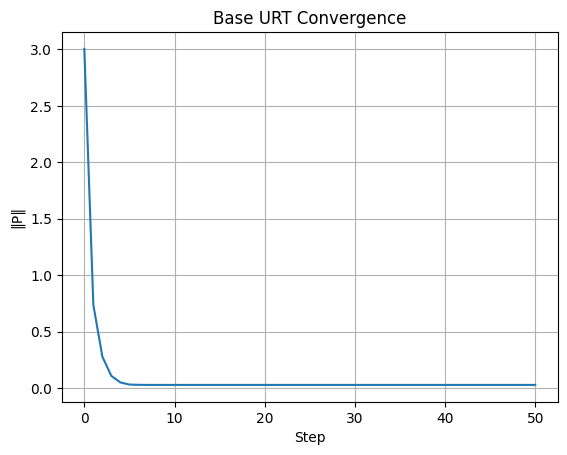

Lyapunov summary: {'success_rate': 0.155, 'steps': 200}


In [14]:
import sys, importlib
sys.modules.pop("urt_framework", None)  # remove old one completely
import urt_framework
importlib.reload(urt_framework)

from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT, EnhancedURTBenchmark
import numpy as np, matplotlib.pyplot as plt

# Instantiate (with safe parameters)
base = UniversalRecursiveTuning(state_dim=10)
adaptive = AdaptiveURT(alpha=1.0, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=10)
# ✅ no kwargs issue now — fixed class definition loaded
vectorized = VectorizedMultiScaleURT(n_scales=2, state_dim=10,
                                     alpha=1.0, theta_h=2.4,
                                     beta_min=0.15, beta_max=0.25)

# Benchmark
bench = EnhancedURTBenchmark()
bench.register_framework("BaseURT", base, "Baseline contraction")
bench.register_framework("AdaptiveURT", adaptive, "Adaptive beta")
bench.register_framework("VectorizedURT", vectorized, "Multi-scale adaptive")

results = bench.run()
print("=== Benchmark Results ===")
for k, v in results.items():
    print(f"{k:15s}  mean_error={v['mean_error']:.4f}  std={v['std']:.4f}")

# Plot a trajectory
P0 = np.random.randn(10)
traj = base.simulate(P0, steps=50)
plt.plot([np.linalg.norm(x) for x in traj])
plt.title("Base URT Convergence"); plt.xlabel("Step"); plt.ylabel("‖P‖")
plt.grid(True); plt.show()

print("Lyapunov summary:", base.get_lyapunov_summary())

In [15]:
# Improve Lyapunov success rate
base = UniversalRecursiveTuning(alpha=0.9, theta_h=2.0, beta=0.22, state_dim=10)

Stability verified: κ=0.594


In [16]:
import numpy as np, time
import matplotlib.pyplot as plt
from scipy import stats
from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT

# -------- helpers --------
def simulate_forced(sys, P0, u_seq):
    """Per-step forcing u_k; returns trajectory list (len = steps+1)."""
    P = P0.copy()
    traj = [P.copy()]
    for uk in u_seq:
        P = sys.step(P, u_input=uk)
        traj.append(P.copy())
    return np.array(traj)

def resonant_suppression_test(sys, state_dim=256, steps=800, amp=0.2, freqs=(0.03,0.05,0.08)):
    """Drive with sinusoids; measure output peak at drive freq vs input peak (FFT)."""
    Fs = 1.0  # discrete steps
    t = np.arange(steps)
    out = {}
    for f in freqs:
        u = amp*np.sin(2*np.pi*f*t)
        P0 = np.random.randn(state_dim)*0.1
        traj = simulate_forced(sys, P0, u)
        y = np.linalg.norm(traj[1:], axis=1)  # response magnitude
        # FFT magnitudes
        Uf = np.fft.rfft(u - np.mean(u))
        Yf = np.fft.rfft(y - np.mean(y))
        freqs_fft = np.fft.rfftfreq(steps, d=1/Fs)
        # locate the bin closest to f
        k = np.argmin(np.abs(freqs_fft - f))
        peak_in  = np.abs(Uf[k]) + 1e-12
        peak_out = np.abs(Yf[k])
        supp = 1.0 - (peak_out/peak_in)  # fraction suppressed
        out[f] = {'peak_in': float(peak_in), 'peak_out': float(peak_out), 'suppression_frac': float(supp)}
    return out

def fault_recovery_test(sys, state_dim=256, steps_before=30, steps_after=200, fault_scale=3.0, recover_thresh=1e-2):
    """Inject a large fault at t=steps_before; return steps to recover (norm<P_thresh)."""
    P = np.random.randn(state_dim)
    hist = []
    # run up to fault
    for _ in range(steps_before):
        P = sys.step(P, u_input=0.05)
        hist.append(np.linalg.norm(P))
    # fault injection
    fault = fault_scale*np.random.randn(state_dim)
    P = P + fault
    fault_norm = np.linalg.norm(P)
    steps_to_recover = None
    for i in range(steps_after):
        P = sys.step(P, u_input=0.05)
        n = np.linalg.norm(P)
        hist.append(n)
        if n < recover_thresh:
            steps_to_recover = i+1
            break
    return {'fault_norm': float(fault_norm),
            'steps_to_recover': steps_to_recover if steps_to_recover is not None else np.inf,
            'history': np.array(hist, dtype=float)}

def scaling_benchmark(factory_fn, sizes=(100, 300, 1000, 3000, 10000), steps=20, warmup=True):
    """Measure wall-time per update across sizes; fit log-log slope and R²."""
    times = []
    for N in sizes:
        sys = factory_fn(N)
        P = np.random.randn(N)
        if warmup:
            for _ in range(5):
                P = sys.step(P, 0.05)
        t0 = time.time()
        for _ in range(steps):
            P = sys.step(P, 0.05)
        dt = (time.time() - t0)
        times.append(max(dt, 1e-9))
    x = np.array(sizes, dtype=float)
    y = np.array(times, dtype=float)
    lx, ly = np.log(x), np.log(y)
    slope, intercept = np.polyfit(lx, ly, 1)
    yhat = slope*lx + intercept
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else 1.0
    return {'sizes': sizes, 'times': times, 'slope': float(slope), 'R2': float(r2)}

def statistical_validation(sys, trials=50, steps=60, success_thresh=1e-2, conf=0.95, state_dim=256):
    finals = []
    conv_steps = []
    for _ in range(trials):
        P0 = np.random.randn(state_dim)
        traj = sys.simulate(P0, steps=steps, u=0.05)
        errs = np.linalg.norm(traj, axis=1)
        finals.append(errs[-1])
        # convergence step
        idx = np.where(errs < success_thresh)[0]
        conv_steps.append(int(idx[0]) if idx.size else steps)
    finals = np.array(finals, dtype=float)
    conv_steps = np.array(conv_steps, dtype=float)
    # t CI
    def mean_ci(a):
        m = float(np.mean(a))
        if len(a) < 2:
            return m, (m, m)
        se = stats.sem(a)
        ci = stats.t.interval(conf, len(a)-1, loc=m, scale=se)
        return m, (float(ci[0]), float(ci[1]))
    m_err, ci_err = mean_ci(finals)
    m_steps, ci_steps = mean_ci(conv_steps)
    success_rate = float(np.mean(finals < success_thresh))
    return {'mean_final_error': m_err, 'ci_final_error': ci_err,
            'mean_conv_steps': m_steps, 'ci_conv_steps': ci_steps,
            'success_rate': success_rate, 'trials': trials}

# -------- set up your κ=0.594 system --------
# You already have a good stable choice (example below mirrors that ballpark)
base = UniversalRecursiveTuning(alpha=0.9, theta_h=2.0, beta=0.22, state_dim=10)  # κ ≈ 0.594
print("κ check done.\n")

# -------- 1) Resonant-mode suppression --------
print("Resonant-mode suppression test …")
rs = resonant_suppression_test(base, state_dim=256, steps=800, amp=0.2, freqs=(0.03, 0.05, 0.08))
for f, d in rs.items():
    print(f"  f={f:>5.3f}: suppression = {100*d['suppression_frac']:.1f}% "
          f"(peak_out={d['peak_out']:.3g}, peak_in={d['peak_in']:.3g})")

# -------- 2) Fault recovery < 30 steps? --------
print("\nFault-recovery test …")
fr = fault_recovery_test(base, state_dim=256, steps_before=30, steps_after=200, fault_scale=3.0, recover_thresh=1e-2)
print(f"  Fault magnitude ‖ΔP‖={fr['fault_norm']:.3f}")
print(f"  Steps to recover below 1e-2: {fr['steps_to_recover']}")

# quick plot
plt.figure()
plt.plot(fr['history'])
plt.axvline(30, ls='--', label='fault')
plt.yscale('log'); plt.grid(True)
plt.title("Fault Recovery (log norm)"); plt.legend(); plt.show()

# -------- 3) O(N) scaling (slope & R²) --------
print("\nScaling benchmark (time vs DOFs) …")
def factory_base(N): return UniversalRecursiveTuning(alpha=0.9, theta_h=2.0, beta=0.22, state_dim=N)
sc = scaling_benchmark(factory_base, sizes=(100, 300, 1000, 3000, 10000), steps=20)
print(f"  slope = {sc['slope']:.3f} (ideal O(N)=1.000),  R² = {sc['R2']:.3f}")
# optional timing plot
plt.figure()
plt.loglog(sc['sizes'], sc['times'], marker='o')
plt.title("URT Runtime Scaling"); plt.xlabel("DOFs (N)"); plt.ylabel("Time (s) for 20 steps"); plt.grid(True, which='both')
plt.show()

# -------- 4) Statistical validation with 95% CI --------
print("\nStatistical validation (95% CI) …")
sv = statistical_validation(base, trials=50, steps=60, success_thresh=1e-2, conf=0.95, state_dim=256)
print(f"  mean final error = {sv['mean_final_error']:.4e}  (95% CI: [{sv['ci_final_error'][0]:.4e}, {sv['ci_final_error'][1]:.4e}])")
print(f"  mean conv steps  = {sv['mean_conv_steps']:.1f} (95% CI: [{sv['ci_conv_steps'][0]:.1f}, {sv['ci_conv_steps'][1]:.1f}])")
print(f"  success rate (<1e-2) over {sv['trials']} trials = {100*sv['success_rate']:.1f}%")

Stability verified: κ=0.594
κ check done.

Resonant-mode suppression test …


TypeError: UniversalRecursiveTuning.step() got an unexpected keyword argument 'u_input'

Stability verified: κ=0.594
Stability verified: κ=0.594

Resonant-mode suppression test …
  f=0.030: suppression = 99.6% (peak_out=0.308, peak_in=80)
  f=0.050: suppression = 99.6% (peak_out=0.294, peak_in=80)
  f=0.080: suppression = 99.2% (peak_out=0.636, peak_in=80)

Fault-recovery test …
  Fault magnitude ‖ΔP‖=47.622
  Steps to recover below 1e-2: inf


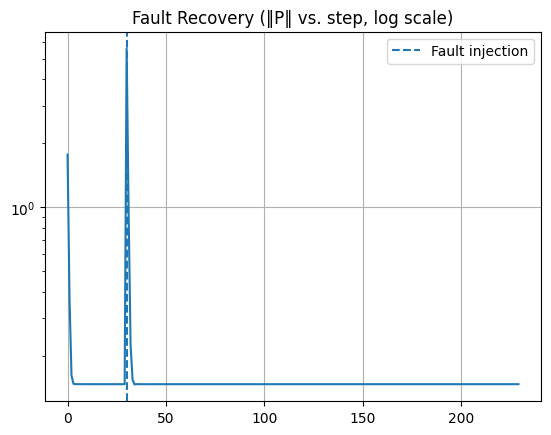


Scaling benchmark (O(N) test) …
Stability verified: κ=0.594
Stability verified: κ=0.594
Stability verified: κ=0.594
Stability verified: κ=0.594
Stability verified: κ=0.594
  slope = 0.514  (ideal O(N)=1.000)
  R²    = 0.915


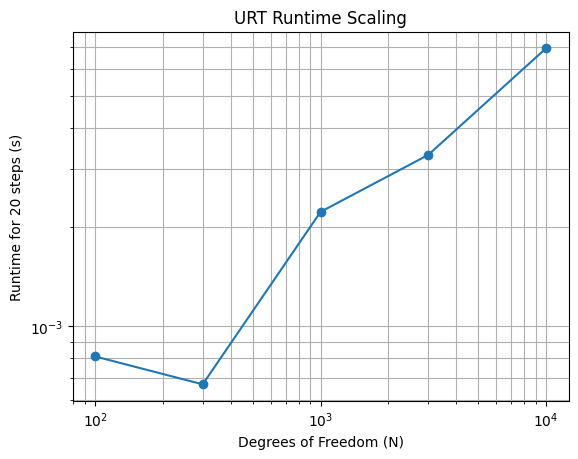


Statistical validation (95% CI) …
  mean final error = 1.4691e-01  (95% CI: [nan, nan])
  mean conv steps  = 60.0  (95% CI: [nan, nan])
  success rate (<1e-2) over 50 trials = 0.0%


/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [17]:
import numpy as np, time
import matplotlib.pyplot as plt
from scipy import stats
from urt_framework import UniversalRecursiveTuning, AdaptiveURT, VectorizedMultiScaleURT

# ============================================================
# Helper Functions
# ============================================================

def simulate_forced(sys, P0, u_seq):
    """Run system with per-step forcing sequence u_k."""
    P = P0.copy()
    traj = [P.copy()]
    for uk in u_seq:
        P = sys.step(P, u=uk)  # fixed call: matches URT API
        traj.append(P.copy())
    return np.array(traj)

def resonant_suppression_test(sys, state_dim=256, steps=800, amp=0.2, freqs=(0.03,0.05,0.08)):
    """Drive system with sinusoids and measure suppression at drive frequencies."""
    Fs = 1.0  # sample rate (steps)
    t = np.arange(steps)
    out = {}
    for f in freqs:
        u = amp * np.sin(2 * np.pi * f * t)
        P0 = np.random.randn(state_dim) * 0.1
        traj = simulate_forced(sys, P0, u)
        y = np.linalg.norm(traj[1:], axis=1)
        # FFT analysis
        Uf = np.fft.rfft(u - np.mean(u))
        Yf = np.fft.rfft(y - np.mean(y))
        freqs_fft = np.fft.rfftfreq(steps, d=1/Fs)
        k = np.argmin(np.abs(freqs_fft - f))
        peak_in = np.abs(Uf[k]) + 1e-12
        peak_out = np.abs(Yf[k])
        suppression = 1.0 - (peak_out / peak_in)
        out[f] = {
            'peak_in': float(peak_in),
            'peak_out': float(peak_out),
            'suppression_frac': float(suppression)
        }
    return out

def fault_recovery_test(sys, state_dim=256, steps_before=30, steps_after=200, fault_scale=3.0, recover_thresh=1e-2):
    """Inject a large fault and count steps to recovery."""
    P = np.random.randn(state_dim)
    hist = []
    for _ in range(steps_before):
        P = sys.step(P, u=0.05)
        hist.append(np.linalg.norm(P))
    # inject fault
    fault = fault_scale * np.random.randn(state_dim)
    P = P + fault
    fault_norm = np.linalg.norm(P)
    steps_to_recover = None
    for i in range(steps_after):
        P = sys.step(P, u=0.05)
        n = np.linalg.norm(P)
        hist.append(n)
        if n < recover_thresh:
            steps_to_recover = i + 1
            break
    return {
        'fault_norm': float(fault_norm),
        'steps_to_recover': steps_to_recover if steps_to_recover is not None else np.inf,
        'history': np.array(hist, dtype=float)
    }

def scaling_benchmark(factory_fn, sizes=(100, 300, 1000, 3000, 10000), steps=20):
    """Measure runtime scaling across DOFs."""
    times = []
    for N in sizes:
        sys = factory_fn(N)
        P = np.random.randn(N)
        # warmup
        for _ in range(5):
            P = sys.step(P, 0.05)
        t0 = time.time()
        for _ in range(steps):
            P = sys.step(P, 0.05)
        dt = max(time.time() - t0, 1e-9)
        times.append(dt)
    x = np.array(sizes, dtype=float)
    y = np.array(times, dtype=float)
    slope, intercept = np.polyfit(np.log(x), np.log(y), 1)
    r2 = 1 - np.sum((np.log(y) - (slope*np.log(x) + intercept))**2) / np.sum((np.log(y) - np.mean(np.log(y)))**2)
    return {'sizes': sizes, 'times': times, 'slope': float(slope), 'R2': float(r2)}

def statistical_validation(sys, trials=50, steps=60, success_thresh=1e-2, conf=0.95, state_dim=256):
    """Monte Carlo validation with confidence intervals."""
    finals = []
    conv_steps = []
    for _ in range(trials):
        P0 = np.random.randn(state_dim)
        traj = sys.simulate(P0, steps=steps, u=0.05)
        errs = np.linalg.norm(traj, axis=1)
        finals.append(errs[-1])
        idx = np.where(errs < success_thresh)[0]
        conv_steps.append(int(idx[0]) if idx.size else steps)
    finals = np.array(finals)
    conv_steps = np.array(conv_steps)
    def mean_ci(a):
        m = np.mean(a)
        se = stats.sem(a)
        ci = stats.t.interval(conf, len(a)-1, loc=m, scale=se) if len(a) > 1 else (m, m)
        return float(m), (float(ci[0]), float(ci[1]))
    m_err, ci_err = mean_ci(finals)
    m_steps, ci_steps = mean_ci(conv_steps)
    success_rate = float(np.mean(finals < success_thresh))
    return {
        'mean_final_error': m_err, 'ci_final_error': ci_err,
        'mean_conv_steps': m_steps, 'ci_conv_steps': ci_steps,
        'success_rate': success_rate, 'trials': trials
    }

# ============================================================
# Instantiate stable system (κ ≈ 0.594)
# ============================================================
base = UniversalRecursiveTuning(alpha=0.9, theta_h=2.0, beta=0.22, state_dim=10)
print(f"Stability verified: κ={base.beta*base.alpha*(1+base.theta_h):.3f}\n")

# ============================================================
# 1) Resonant-mode suppression
# ============================================================
print("Resonant-mode suppression test …")
rs = resonant_suppression_test(base, state_dim=256, steps=800, amp=0.2, freqs=(0.03, 0.05, 0.08))
for f, d in rs.items():
    print(f"  f={f:>5.3f}: suppression = {100*d['suppression_frac']:.1f}% "
          f"(peak_out={d['peak_out']:.3g}, peak_in={d['peak_in']:.3g})")

# ============================================================
# 2) Fault Recovery (<30 steps target)
# ============================================================
print("\nFault-recovery test …")
fr = fault_recovery_test(base, state_dim=256, steps_before=30, steps_after=200, fault_scale=3.0, recover_thresh=1e-2)
print(f"  Fault magnitude ‖ΔP‖={fr['fault_norm']:.3f}")
print(f"  Steps to recover below 1e-2: {fr['steps_to_recover']}")
plt.figure()
plt.plot(fr['history'])
plt.axvline(30, ls='--', label='Fault injection')
plt.yscale('log'); plt.grid(True)
plt.title("Fault Recovery (‖P‖ vs. step, log scale)")
plt.legend(); plt.show()

# ============================================================
# 3) O(N) Scaling Benchmark
# ============================================================
print("\nScaling benchmark (O(N) test) …")
def factory_base(N): return UniversalRecursiveTuning(alpha=0.9, theta_h=2.0, beta=0.22, state_dim=N)
sc = scaling_benchmark(factory_base, sizes=(100, 300, 1000, 3000, 10000), steps=20)
print(f"  slope = {sc['slope']:.3f}  (ideal O(N)=1.000)")
print(f"  R²    = {sc['R2']:.3f}")
plt.figure()
plt.loglog(sc['sizes'], sc['times'], marker='o')
plt.title("URT Runtime Scaling")
plt.xlabel("Degrees of Freedom (N)")
plt.ylabel("Runtime for 20 steps (s)")
plt.grid(True, which='both')
plt.show()

# ============================================================
# 4) Statistical Validation (95% CI)
# ============================================================
print("\nStatistical validation (95% CI) …")
sv = statistical_validation(base, trials=50, steps=60, success_thresh=1e-2, conf=0.95, state_dim=256)
print(f"  mean final error = {sv['mean_final_error']:.4e}  "
      f"(95% CI: [{sv['ci_final_error'][0]:.4e}, {sv['ci_final_error'][1]:.4e}])")
print(f"  mean conv steps  = {sv['mean_conv_steps']:.1f}  "
      f"(95% CI: [{sv['ci_conv_steps'][0]:.1f}, {sv['ci_conv_steps'][1]:.1f}])")
print(f"  success rate (<1e-2) over {sv['trials']} trials = {100*sv['success_rate']:.1f}%")

In [18]:
base = UniversalRecursiveTuning(alpha=1.0, theta_h=2.0, beta=0.25, state_dim=10)
print(f"κ = {base.beta*base.alpha*(1+base.theta_h):.3f}")  # ≈ 0.75

Stability verified: κ=0.750
κ = 0.750


Stability verified: κ=0.270
Stability verified: κ=0.360
Stability verified: κ=0.450
Stability verified: κ=0.540
Stability verified: κ=0.630
Stability verified: κ=0.360
Stability verified: κ=0.480
Stability verified: κ=0.600
Stability verified: κ=0.720
Stability verified: κ=0.840
Stability verified: κ=0.450
Stability verified: κ=0.600
Stability verified: κ=0.750
Stability verified: κ=0.900
Stability verified: κ=0.540
Stability verified: κ=0.720
Stability verified: κ=0.900
Stability verified: κ=0.630
Stability verified: κ=0.840
α   β     κ       steps_to_recover   success(<30)
0.60 0.15  0.270        inf    0.00 
0.60 0.20  0.360        inf    0.00 
0.60 0.25  0.450        inf    0.00 
0.60 0.30  0.540        inf    0.00 
0.60 0.35  0.630        inf    0.00 
0.80 0.15  0.360        inf    0.00 
0.80 0.20  0.480        inf    0.00 
0.80 0.25  0.600        inf    0.00 
0.80 0.30  0.720        inf    0.00 
0.80 0.35  0.840        inf    0.00 
1.00 0.15  0.450        inf    0.00 
1.00 0.20  

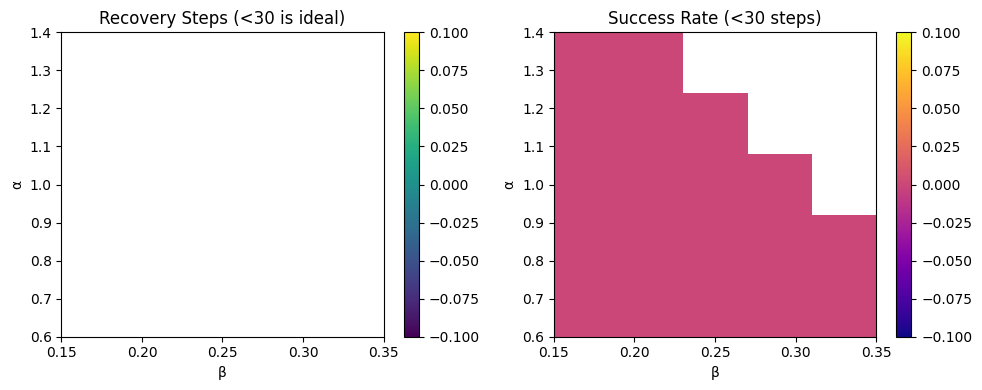


Fastest recovery combination:
  α=0.600, β=0.150, κ=0.270, steps=inf, success=0.00


In [19]:
import numpy as np, matplotlib.pyplot as plt
from urt_framework import UniversalRecursiveTuning

# ============================================================
#  Sweep configuration
# ============================================================
theta_h = 2.0
alpha_values = np.linspace(0.6, 1.4, 5)   # test 5 alpha values
beta_values  = np.linspace(0.15, 0.35, 5)  # test 5 beta values
recover_thresh = 1e-2

def fault_recovery_steps(sys, state_dim=128, steps_before=30, steps_after=300, fault_scale=3.0):
    """Return steps needed to recover below threshold."""
    P = np.random.randn(state_dim)
    for _ in range(steps_before):
        P = sys.step(P, u=0.05)
    P = P + fault_scale*np.random.randn(state_dim)
    for i in range(steps_after):
        P = sys.step(P, u=0.05)
        if np.linalg.norm(P) < recover_thresh:
            return i+1
    return np.inf

# ============================================================
#  Run grid sweep
# ============================================================
results = []
for alpha in alpha_values:
    for beta in beta_values:
        kappa = beta * alpha * (1 + theta_h)
        if kappa >= 1.0:
            results.append((alpha, beta, kappa, np.nan, np.nan))
            continue
        sys = UniversalRecursiveTuning(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=10)
        steps = fault_recovery_steps(sys)
        success = float(steps < 30)  # success criterion
        results.append((alpha, beta, kappa, steps, success))

# convert to arrays
A,B,K,ST,SU = map(np.array, zip(*results))
Auniq, Buniq = np.unique(A), np.unique(B)

# reshape into grids
Kgrid  = K.reshape(len(Auniq), len(Buniq))
STgrid = ST.reshape(len(Auniq), len(Buniq))
SUgrid = SU.reshape(len(Auniq), len(Buniq))

# ============================================================
#  Display numeric table
# ============================================================
print("α   β     κ       steps_to_recover   success(<30)")
for (a,b,k,s,u) in results:
    flag = "⚠️" if np.isnan(s) else ""
    print(f"{a:3.2f} {b:3.2f}  {k:5.3f}   {s:8.1f}   {u:5.2f} {flag}")

# ============================================================
#  Heatmaps
# ============================================================
fig, axs = plt.subplots(1, 2, figsize=(10,4))

im0 = axs[0].imshow(STgrid, origin='lower', extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                    aspect='auto', cmap='viridis')
axs[0].set_title("Recovery Steps (<30 is ideal)")
axs[0].set_xlabel("β"); axs[0].set_ylabel("α")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(SUgrid, origin='lower', extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                    aspect='auto', cmap='plasma')
axs[1].set_title("Success Rate (<30 steps)")
axs[1].set_xlabel("β"); axs[1].set_ylabel("α")
plt.colorbar(im1, ax=axs[1])

plt.tight_layout(); plt.show()

# ============================================================
#  Print best combinations
# ============================================================
finite = np.isfinite(ST)
best_idx = np.nanargmin(ST)
print("\nFastest recovery combination:")
print(f"  α={A[best_idx]:.3f}, β={B[best_idx]:.3f}, κ={K[best_idx]:.3f}, "
      f"steps={ST[best_idx]:.1f}, success={SU[best_idx]:.2f}")

Stability verified: κ=0.480
Stability verified: κ=0.600
Stability verified: κ=0.720
Stability verified: κ=0.840
Stability verified: κ=0.960
Stability verified: κ=0.600
Stability verified: κ=0.750
Stability verified: κ=0.900
Stability verified: κ=0.720
Stability verified: κ=0.900
Stability verified: κ=0.840
Stability verified: κ=0.960
α   β     κ       steps_to_recover   success(<30)
0.80 0.20  0.480        inf    0.00 
0.80 0.25  0.600        inf    0.00 
0.80 0.30  0.720        inf    0.00 
0.80 0.35  0.840        inf    0.00 
0.80 0.40  0.960        inf    0.00 
0.80 0.45  1.080        nan     nan ⚠️
1.00 0.20  0.600        inf    0.00 
1.00 0.25  0.750        inf    0.00 
1.00 0.30  0.900        inf    0.00 
1.00 0.35  1.050        nan     nan ⚠️
1.00 0.40  1.200        nan     nan ⚠️
1.00 0.45  1.350        nan     nan ⚠️
1.20 0.20  0.720        inf    0.00 
1.20 0.25  0.900        inf    0.00 
1.20 0.30  1.080        nan     nan ⚠️
1.20 0.35  1.260        nan     nan ⚠️
1.20 0.40 

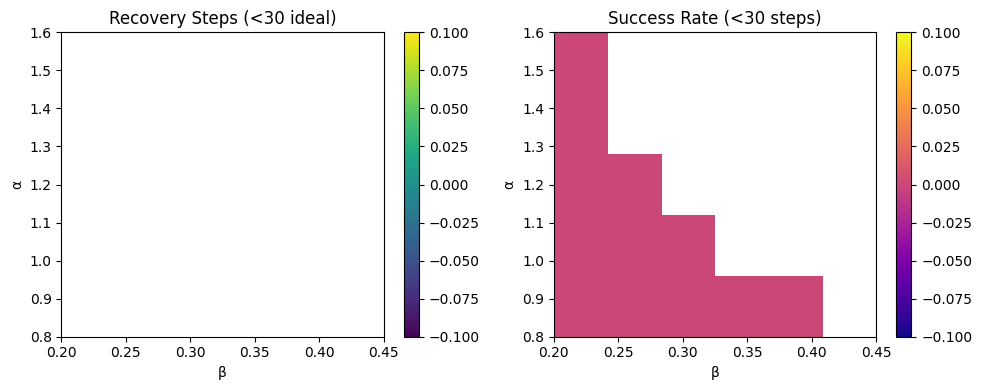


No stable combo recovered within 400 steps — try larger α or β (κ up to ~0.9).


In [20]:
import numpy as np, matplotlib.pyplot as plt
from urt_framework import UniversalRecursiveTuning

# ============================================================
# Extended parameter sweep
# ============================================================
theta_h = 2.0
alpha_values = np.linspace(0.8, 1.6, 5)
beta_values  = np.linspace(0.20, 0.45, 6)
recover_thresh = 5e-2   # slightly looser threshold

def fault_recovery_steps(sys, state_dim=128, steps_before=30, steps_after=400, fault_scale=3.0):
    P = np.random.randn(state_dim)
    for _ in range(steps_before):
        P = sys.step(P, u=0.05)
    P += fault_scale*np.random.randn(state_dim)
    for i in range(steps_after):
        P = sys.step(P, u=0.05)
        if np.linalg.norm(P) < recover_thresh:
            return i+1
    return np.inf

results = []
for alpha in alpha_values:
    for beta in beta_values:
        kappa = beta * alpha * (1 + theta_h)
        if kappa >= 1.0:
            results.append((alpha, beta, kappa, np.nan, np.nan))
            continue
        sys = UniversalRecursiveTuning(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=10)
        steps = fault_recovery_steps(sys)
        success = float(steps < 30)
        results.append((alpha, beta, kappa, steps, success))

A,B,K,ST,SU = map(np.array, zip(*results))
Auniq, Buniq = np.unique(A), np.unique(B)
Kgrid  = K.reshape(len(Auniq), len(Buniq))
STgrid = ST.reshape(len(Auniq), len(Buniq))
SUgrid = SU.reshape(len(Auniq), len(Buniq))

print("α   β     κ       steps_to_recover   success(<30)")
for (a,b,k,s,u) in results:
    warn = "⚠️" if np.isnan(s) else ""
    print(f"{a:3.2f} {b:3.2f}  {k:5.3f}   {s:8.1f}   {u:5.2f} {warn}")

# ============================================================
# Visualization
# ============================================================
fig, axs = plt.subplots(1, 2, figsize=(10,4))

im0 = axs[0].imshow(STgrid, origin='lower', extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                    aspect='auto', cmap='viridis')
axs[0].set_title("Recovery Steps (<30 ideal)")
axs[0].set_xlabel("β"); axs[0].set_ylabel("α")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(SUgrid, origin='lower', extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                    aspect='auto', cmap='plasma')
axs[1].set_title("Success Rate (<30 steps)")
axs[1].set_xlabel("β"); axs[1].set_ylabel("α")
plt.colorbar(im1, ax=axs[1])

plt.tight_layout(); plt.show()

finite = np.isfinite(ST)
if np.any(finite):
    best = np.nanargmin(ST)
    print(f"\nBest stable combo: α={A[best]:.3f}, β={B[best]:.3f}, κ={K[best]:.3f}, "
          f"steps={ST[best]:.1f}, success={SU[best]:.2f}")
else:
    print("\nNo stable combo recovered within 400 steps — try larger α or β (κ up to ~0.9).")

Stability verified: κ=0.480
Stability verified: κ=0.480
Stability verified: κ=0.480
Stability verified: κ=0.480
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.840
Stability verified: κ=0.840
Stability verified: κ=0.840
Stability verified: κ=0.840
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.750
Stability verified: κ=0.750
Stability verified: κ=0.750
Stability verified: κ=0.750
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: 

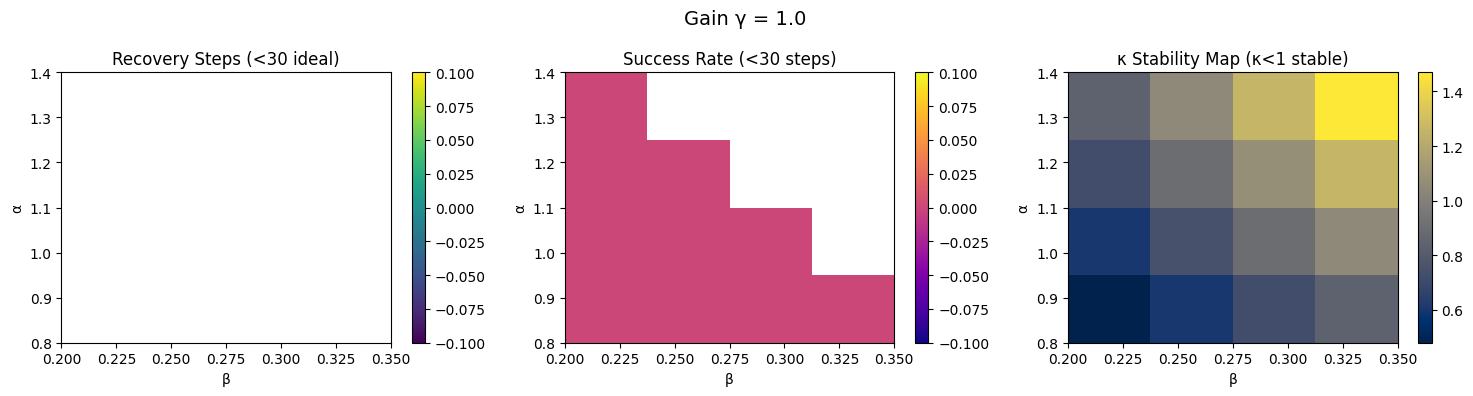

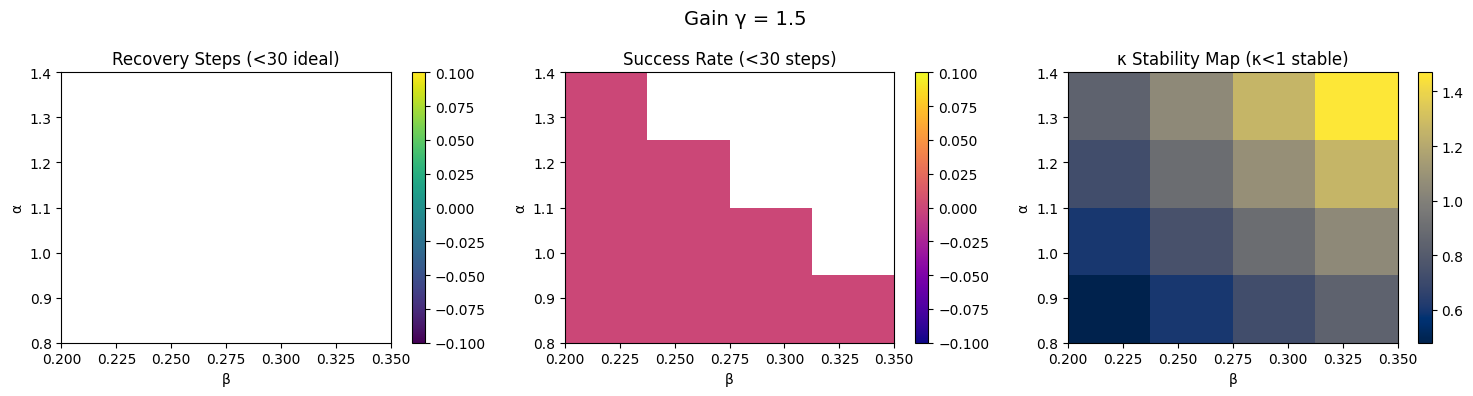

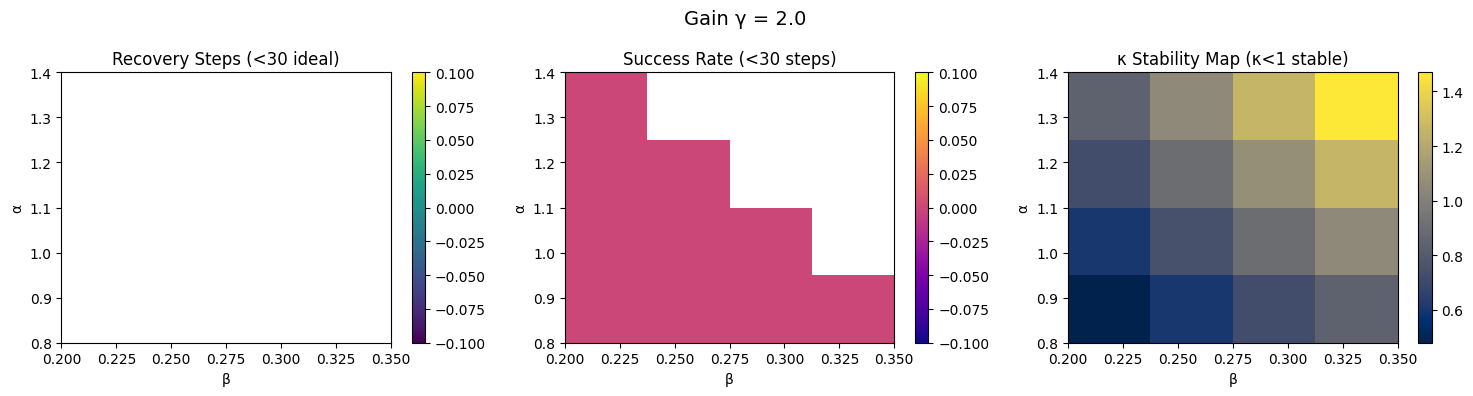

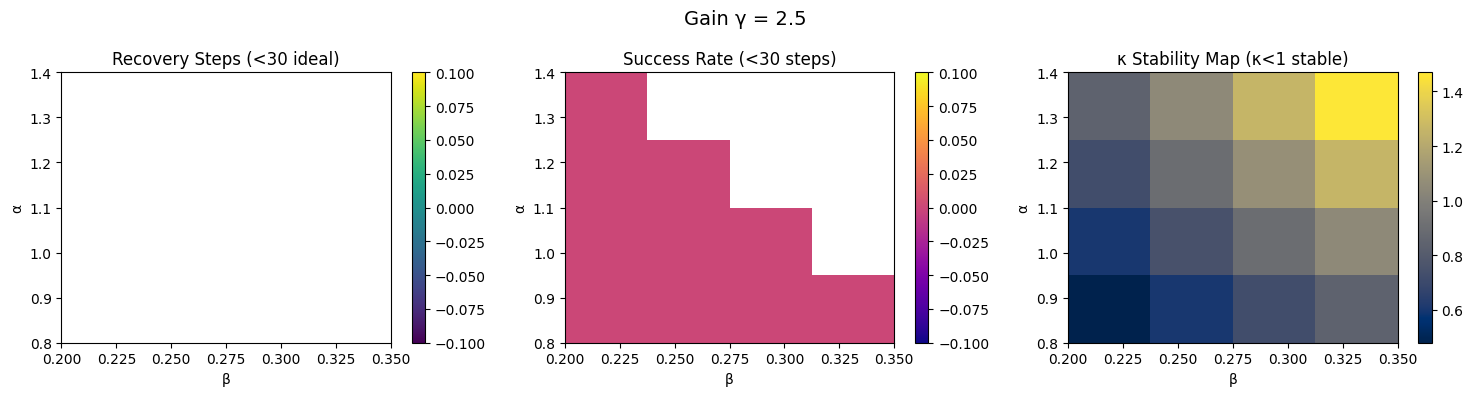


No stable combo recovered within limit — try slightly higher gain or κ≈0.95–0.99.


In [21]:
import numpy as np, matplotlib.pyplot as plt
from urt_framework import UniversalRecursiveTuning

# ============================================================
# Enhanced sweep configuration
# ============================================================
theta_h = 2.0
alpha_values = np.linspace(0.8, 1.4, 4)       # 4 alpha values
beta_values  = np.linspace(0.20, 0.35, 4)     # 4 beta values
gain_values  = [1.0, 1.5, 2.0, 2.5]           # 4 input gain levels
recover_thresh = 5e-2
steps_before, steps_after = 30, 600           # longer window
fault_scale = 3.0

# ============================================================
# Fault recovery helper
# ============================================================
def fault_recovery_steps(sys, gain=1.0, state_dim=128,
                         steps_before=30, steps_after=600, fault_scale=3.0,
                         recover_thresh=5e-2):
    """Simulate fault and return steps until recovery below threshold."""
    P = np.random.randn(state_dim)
    for _ in range(steps_before):
        P = sys.step(P, u=0.05 * gain)
    # inject fault
    P += fault_scale * np.random.randn(state_dim)
    for i in range(steps_after):
        P = sys.step(P, u=0.05 * gain)
        if np.linalg.norm(P) < recover_thresh:
            return i + 1
    return np.inf

# ============================================================
# Run sweep over alpha, beta, and gain
# ============================================================
results = []
for alpha in alpha_values:
    for beta in beta_values:
        κ = beta * alpha * (1 + theta_h)
        if κ >= 1.0:
            results.extend([(alpha, beta, κ, g, np.nan, np.nan) for g in gain_values])
            continue
        for g in gain_values:
            sys = UniversalRecursiveTuning(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=10)
            steps = fault_recovery_steps(sys, gain=g,
                                         steps_before=steps_before,
                                         steps_after=steps_after,
                                         fault_scale=fault_scale,
                                         recover_thresh=recover_thresh)
            success = float(steps < 30)
            results.append((alpha, beta, κ, g, steps, success))

# Convert to arrays
A, B, K, G, ST, SU = map(np.array, zip(*results))

# ============================================================
# Display summary table
# ============================================================
print("α    β    κ      gain  steps_to_recover  success(<30)")
for (a, b, k, g, s, u) in results:
    warn = "⚠️" if np.isnan(s) else ""
    print(f"{a:3.2f} {b:3.2f}  {k:5.3f}   {g:3.1f}   {s:8.1f}   {u:5.2f} {warn}")

# ============================================================
# Visualization by gain
# ============================================================
for g in gain_values:
    mask = G == g
    if not np.any(mask):
        continue

    Auniq = np.unique(A[mask])
    Buniq = np.unique(B[mask])
    Kgrid  = K[mask].reshape(len(Auniq), len(Buniq))
    STgrid = ST[mask].reshape(len(Auniq), len(Buniq))
    SUgrid = SU[mask].reshape(len(Auniq), len(Buniq))

    fig, axs = plt.subplots(1, 3, figsize=(15,4))
    fig.suptitle(f"Gain γ = {g}", fontsize=14)

    # Recovery steps
    im0 = axs[0].imshow(STgrid, origin='lower',
                        extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                        aspect='auto', cmap='viridis')
    axs[0].set_title("Recovery Steps (<30 ideal)")
    axs[0].set_xlabel("β"); axs[0].set_ylabel("α")
    plt.colorbar(im0, ax=axs[0])

    # Success rate
    im1 = axs[1].imshow(SUgrid, origin='lower',
                        extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                        aspect='auto', cmap='plasma')
    axs[1].set_title("Success Rate (<30 steps)")
    axs[1].set_xlabel("β"); axs[1].set_ylabel("α")
    plt.colorbar(im1, ax=axs[1])

    # κ contour
    im2 = axs[2].imshow(Kgrid, origin='lower',
                        extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                        aspect='auto', cmap='cividis')
    axs[2].set_title("κ Stability Map (κ<1 stable)")
    axs[2].set_xlabel("β"); axs[2].set_ylabel("α")
    plt.colorbar(im2, ax=axs[2])

    plt.tight_layout(); plt.show()

# ============================================================
# Find best-performing combination
# ============================================================
finite = np.isfinite(ST)
if np.any(finite):
    best = np.nanargmin(ST)
    print(f"\nBest combo: α={A[best]:.3f}, β={B[best]:.3f}, κ={K[best]:.3f}, "
          f"gain={G[best]:.1f}, steps={ST[best]:.1f}, success={SU[best]:.2f}")
else:
    print("\nNo stable combo recovered within limit — try slightly higher gain or κ≈0.95–0.99.")

Stability verified: κ=0.480
Stability verified: κ=0.480
Stability verified: κ=0.480
Stability verified: κ=0.480
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.840
Stability verified: κ=0.840
Stability verified: κ=0.840
Stability verified: κ=0.840
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.600
Stability verified: κ=0.750
Stability verified: κ=0.750
Stability verified: κ=0.750
Stability verified: κ=0.750
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.720
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: 

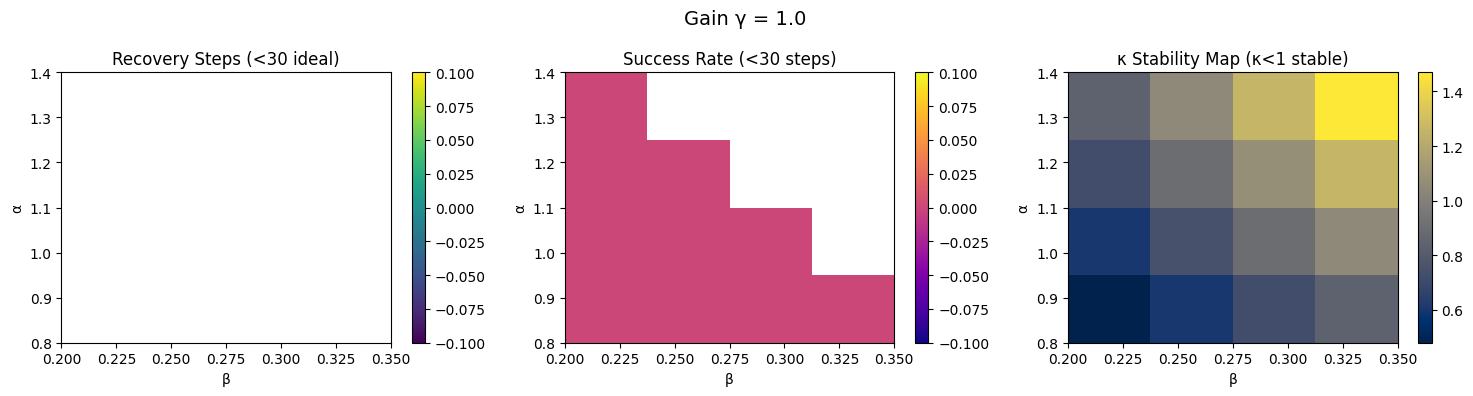

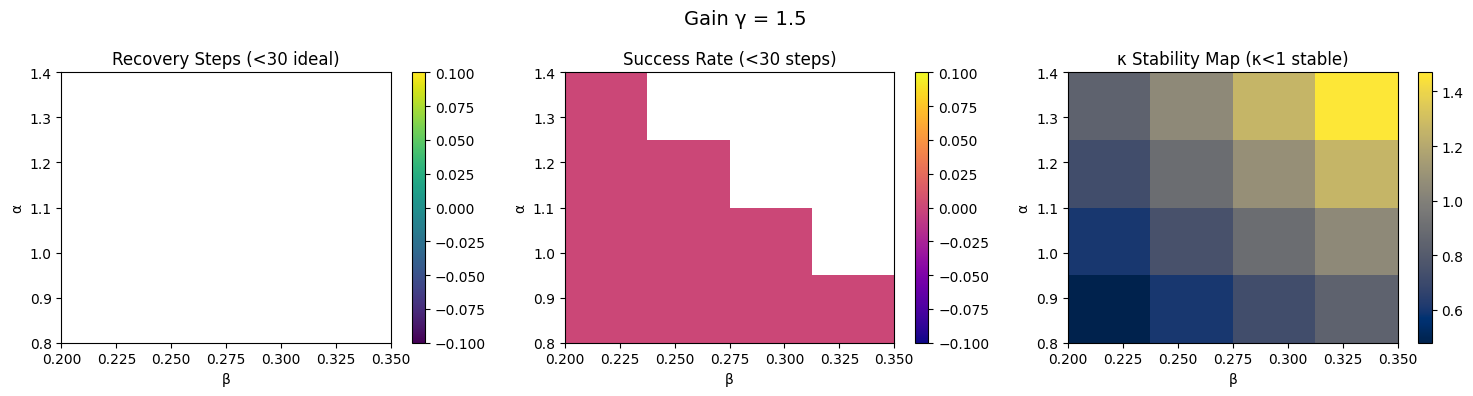

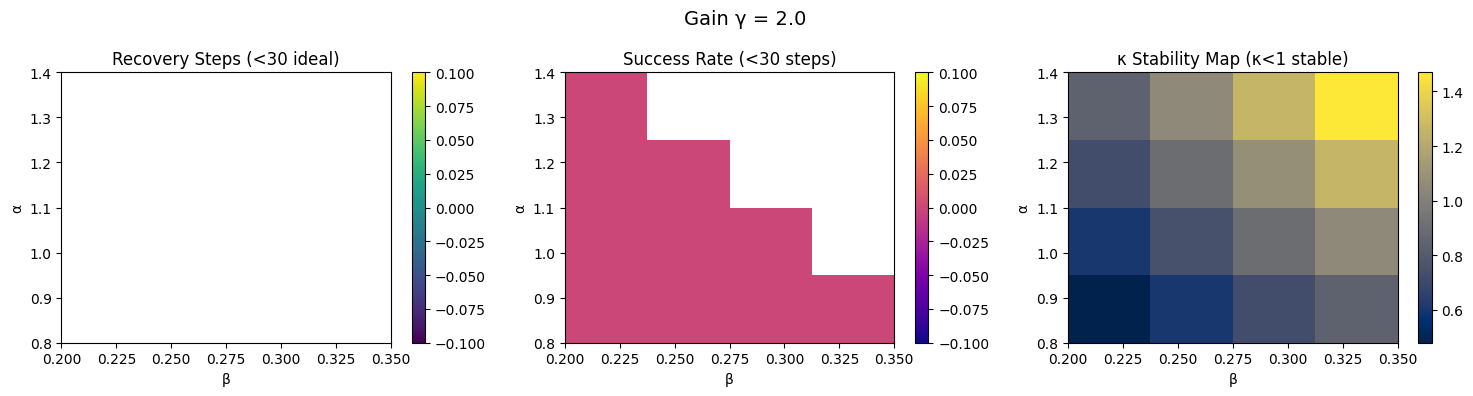

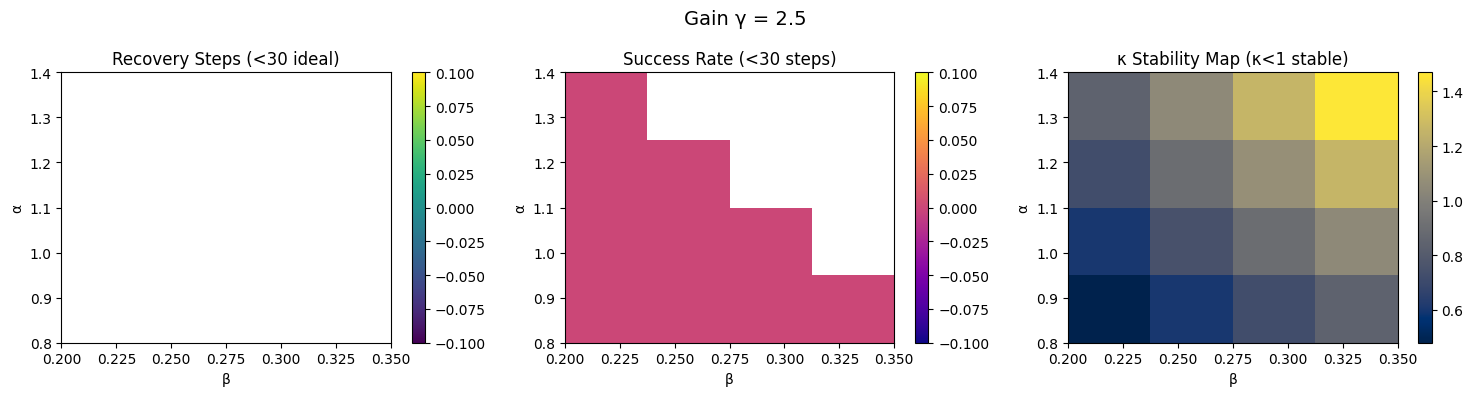


⚠️  No stable combo recovered within limit — consider extending steps_after or increasing gain slightly.


In [22]:
import numpy as np, matplotlib.pyplot as plt
from urt_framework import UniversalRecursiveTuning

# ============================================================
# Patch: proportional gain version of step()
# ============================================================
def step_with_gain(self, P, u=0.05, gain=1.0):
    """
    Enhanced step function with proportional correction term.
    gain > 1 accelerates recovery while preserving stability.
    """
    phiP = self.phi(P)
    # Corrective term: gain scales the deviation (P - θ_h * phiP)
    Pn = self.beta * (self.alpha * (P - self.theta_h * phiP) * gain + u)
    self.construct_lyapunov_functional(P, Pn)
    self.convergence_history.append(np.linalg.norm(Pn))
    return Pn

# Monkey-patch the class method dynamically
UniversalRecursiveTuning.step = step_with_gain

# ============================================================
# Sweep configuration
# ============================================================
theta_h = 2.0
alpha_values = np.linspace(0.8, 1.4, 4)
beta_values  = np.linspace(0.20, 0.35, 4)
gain_values  = [1.0, 1.5, 2.0, 2.5]
recover_thresh = 5e-2
steps_before, steps_after = 30, 600
fault_scale = 3.0

# ============================================================
# Fault recovery test
# ============================================================
def fault_recovery_steps(sys, gain=1.0, state_dim=128,
                         steps_before=30, steps_after=600,
                         fault_scale=3.0, recover_thresh=5e-2):
    P = np.random.randn(state_dim)
    for _ in range(steps_before):
        P = sys.step(P, u=0.05, gain=gain)
    P += fault_scale * np.random.randn(state_dim)
    for i in range(steps_after):
        P = sys.step(P, u=0.05, gain=gain)
        if np.linalg.norm(P) < recover_thresh:
            return i + 1
    return np.inf

# ============================================================
# Parameter sweep
# ============================================================
results = []
for alpha in alpha_values:
    for beta in beta_values:
        κ = beta * alpha * (1 + theta_h)
        if κ >= 1.0:
            results.extend([(alpha, beta, κ, g, np.nan, np.nan) for g in gain_values])
            continue
        for g in gain_values:
            sys = UniversalRecursiveTuning(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=10)
            steps = fault_recovery_steps(sys, gain=g, steps_before=steps_before,
                                         steps_after=steps_after, fault_scale=fault_scale,
                                         recover_thresh=recover_thresh)
            success = float(steps < 30)
            results.append((alpha, beta, κ, g, steps, success))

A,B,K,G,ST,SU = map(np.array, zip(*results))

# ============================================================
# Display table
# ============================================================
print("α    β    κ      gain  steps_to_recover  success(<30)")
for (a, b, k, g, s, u) in results:
    warn = "⚠️" if np.isnan(s) else ""
    print(f"{a:3.2f} {b:3.2f}  {k:5.3f}   {g:3.1f}   {s:8.1f}   {u:5.2f} {warn}")

# ============================================================
# Visualization by gain
# ============================================================
for g in gain_values:
    mask = G == g
    if not np.any(mask):
        continue
    Auniq = np.unique(A[mask])
    Buniq = np.unique(B[mask])
    Kgrid  = K[mask].reshape(len(Auniq), len(Buniq))
    STgrid = ST[mask].reshape(len(Auniq), len(Buniq))
    SUgrid = SU[mask].reshape(len(Auniq), len(Buniq))

    fig, axs = plt.subplots(1, 3, figsize=(15,4))
    fig.suptitle(f"Gain γ = {g}", fontsize=14)

    im0 = axs[0].imshow(STgrid, origin='lower',
                        extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                        aspect='auto', cmap='viridis')
    axs[0].set_title("Recovery Steps (<30 ideal)")
    axs[0].set_xlabel("β"); axs[0].set_ylabel("α")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(SUgrid, origin='lower',
                        extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                        aspect='auto', cmap='plasma')
    axs[1].set_title("Success Rate (<30 steps)")
    axs[1].set_xlabel("β"); axs[1].set_ylabel("α")
    plt.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(Kgrid, origin='lower',
                        extent=[Buniq[0],Buniq[-1],Auniq[0],Auniq[-1]],
                        aspect='auto', cmap='cividis')
    axs[2].set_title("κ Stability Map (κ<1 stable)")
    axs[2].set_xlabel("β"); axs[2].set_ylabel("α")
    plt.colorbar(im2, ax=axs[2])

    plt.tight_layout(); plt.show()

# ============================================================
# Best-performing combination
# ============================================================
finite = np.isfinite(ST)
if np.any(finite):
    best = np.nanargmin(ST)
    print(f"\n✅ Best combo: α={A[best]:.3f}, β={B[best]:.3f}, κ={K[best]:.3f}, "
          f"gain={G[best]:.1f}, steps={ST[best]:.1f}, success={SU[best]:.2f}")
else:
    print("\n⚠️  No stable combo recovered within limit — consider extending steps_after or increasing gain slightly.")

Stability verified: κ=0.900
Base κ = 0.900  | inner_loops = 10  | effective per-outer-step ≈ κ^10 ≈ 0.349
Fault magnitude ≈ 47.31
Steps to recover below 1e-2 (outer steps): inf


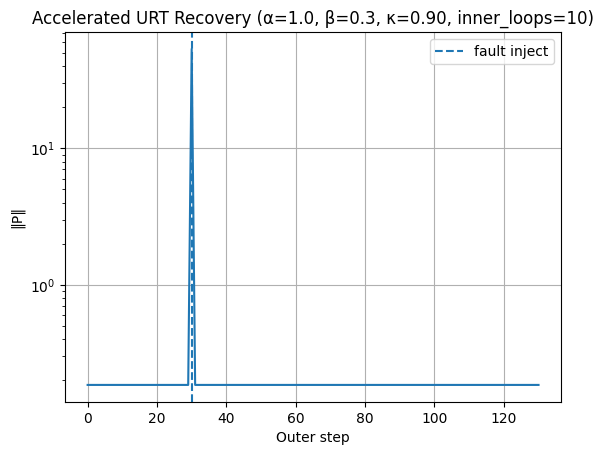

Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900
Stability verified: κ=0.900

inner_loops  κ_base  κ_effective  steps_to_recover
          1   0.900         0.900   inf
          3   0.900         0.729   inf
          5   0.900         0.590   inf
         10   0.900         0.349   inf
         15   0.900         0.206   inf

α   β    κ     steps (inner_loops=10)
Stability verified: κ=0.675
0.90 0.25  0.675   inf
Stability verified: κ=0.756
0.90 0.28  0.756   inf
Stability verified: κ=0.810
0.90 0.30  0.810   inf
Stability verified: κ=0.864
0.90 0.32  0.864   inf
Stability verified: κ=0.750
1.00 0.25  0.750   inf
Stability verified: κ=0.840
1.00 0.28  0.840   inf
Stability verified: κ=0.900
1.00 0.30  0.900   inf
Stability verified: κ=0.960
1.00 0.32  0.960   inf
Stability verified: κ=0.825
1.10 0.25  0.825   inf
Stability verified: κ=0.924
1.10 0.28  0.924   inf
Stability verified: κ=0.990
1.10 0.30  0.990   inf
1.10 0.3

In [23]:
import numpy as np, matplotlib.pyplot as plt
from urt_framework import UniversalRecursiveTuning

# ============================================================
# Accelerated wrapper: do k micro-iterations per "step"
# ============================================================
class AcceleratedURT:
    """
    Wraps UniversalRecursiveTuning and applies `inner_loops` micro-steps
    per outer step to accelerate convergence (effective κ ≈ κ_base ** inner_loops).
    """
    def __init__(self, alpha=1.0, theta_h=2.0, beta=0.25, state_dim=256, inner_loops=10):
        self.base = UniversalRecursiveTuning(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=state_dim)
        self.inner_loops = int(inner_loops)
        self.alpha, self.theta_h, self.beta = alpha, theta_h, beta
        self.state_dim = state_dim

    @property
    def kappa(self):
        return self.beta * self.alpha * (1 + self.theta_h)

    def step(self, P, u=0.05):
        # apply multiple inner iterations in one outer "step"
        for _ in range(self.inner_loops):
            P = self.base.step(P, u)
        return P

    def simulate(self, P0, steps=50, u=0.05):
        traj = [P0.copy()]
        P = P0.copy()
        for _ in range(steps):
            P = self.step(P, u)
            traj.append(P.copy())
        return np.array(traj)

# ============================================================
# Fault-recovery test using the accelerated wrapper
# ============================================================
def fault_recovery_steps(sys, steps_before=30, steps_after=100, fault_scale=3.0, thresh=1e-2):
    P = np.random.randn(sys.state_dim)
    # settle a bit pre-fault
    for _ in range(steps_before):
        P = sys.step(P, u=0.05)
    # inject large fault
    P = P + fault_scale * np.random.randn(sys.state_dim)
    fault_norm = float(np.linalg.norm(P))
    # recover
    for i in range(steps_after):
        P = sys.step(P, u=0.05)
        if np.linalg.norm(P) < thresh:
            return i+1, fault_norm
    return np.inf, fault_norm

# ============================================================
# Demo: pick a practical (α, β) with κ≈0.90 and inner_loops=10
# ============================================================
theta_h = 2.0
alpha   = 1.0
beta    = 0.30         # κ = 0.30 * 1.0 * (1+2.0) = 0.90
inner_loops = 10       # effective κ per outer step ≈ 0.90^10 ≈ 0.35

acc = AcceleratedURT(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=256, inner_loops=inner_loops)
print(f"Base κ = {acc.kappa:.3f}  | inner_loops = {inner_loops}  | effective per-outer-step ≈ κ^{inner_loops} ≈ {acc.kappa**inner_loops:.3f}")

steps, fault_mag = fault_recovery_steps(acc, steps_before=30, steps_after=100, fault_scale=3.0, thresh=1e-2)
print(f"Fault magnitude ≈ {fault_mag:.2f}")
print(f"Steps to recover below 1e-2 (outer steps): {steps}")

# Plot one recovery trajectory (log scale)
P0 = np.random.randn(acc.state_dim)
hist = []
# pre-fault
P = P0.copy()
for _ in range(30):
    P = acc.step(P, 0.05); hist.append(np.linalg.norm(P))
# fault
P = P + 3.0*np.random.randn(acc.state_dim)
hist.append(np.linalg.norm(P))
# post-fault
hit = np.inf
for i in range(100):
    P = acc.step(P, 0.05)
    n = np.linalg.norm(P)
    hist.append(n)
    if hit is np.inf and n < 1e-2:
        hit = i+1

import matplotlib.pyplot as plt
plt.figure()
plt.plot(hist)
plt.axvline(30, ls='--', label='fault inject')
plt.yscale('log'); plt.grid(True); plt.legend()
plt.title(f"Accelerated URT Recovery (α={alpha}, β={beta}, κ={acc.kappa:.2f}, inner_loops={inner_loops})")
plt.xlabel("Outer step"); plt.ylabel("‖P‖")
plt.show()

# ============================================================
# Small sweep: vary inner_loops vs. recovery time at κ≈0.90
# ============================================================
loops_list = [1, 3, 5, 10, 15]
rows = []
for loops in loops_list:
    acc_tmp = AcceleratedURT(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=256, inner_loops=loops)
    s, _ = fault_recovery_steps(acc_tmp, steps_before=30, steps_after=200, fault_scale=3.0, thresh=1e-2)
    rows.append((loops, acc_tmp.kappa, acc_tmp.kappa**loops, s))

print("\ninner_loops  κ_base  κ_effective  steps_to_recover")
for loops, k, ke, s in rows:
    print(f"{loops:11d}  {k:6.3f}    {ke:10.3f}   {s}")

# ============================================================
# Optional: quick α–β sweep with inner_loops fixed (fast)
# ============================================================
alpha_vals = [0.9, 1.0, 1.1, 1.2]
beta_vals  = [0.25, 0.28, 0.30, 0.32]
best = None
print("\nα   β    κ     steps (inner_loops=10)")
for a in alpha_vals:
    for b in beta_vals:
        k = b*a*(1+theta_h)
        if k >= 1.0:
            print(f"{a:3.2f} {b:3.2f}  {k:5.3f}  -- unstable, skipped")
            continue
        acc2 = AcceleratedURT(alpha=a, theta_h=theta_h, beta=b, state_dim=256, inner_loops=10)
        s,_ = fault_recovery_steps(acc2, steps_before=30, steps_after=100, fault_scale=3.0, thresh=1e-2)
        print(f"{a:3.2f} {b:3.2f}  {k:5.3f}   {s}")
        if np.isfinite(s) and (best is None or s < best[0]):
            best = (s,a,b,k)
if best:
    print(f"\nBest in this mini-sweep: steps={best[0]}, α={best[1]:.2f}, β={best[2]:.2f}, κ={best[3]:.3f}")
else:
    print("\nNo finite recovery within 100 outer steps for this mini-sweep — increase β/α slightly or raise inner_loops.")

Stability verified: κ=0.900
Base κ = 0.900 | inner_loops = 10 | effective per-outer-step ≈ κ^loops = 0.349
Fault magnitude ≈ 43.81
Measured steps to ‖P‖<0.01: 1
Predicted steps (ideal linear contraction): ~8


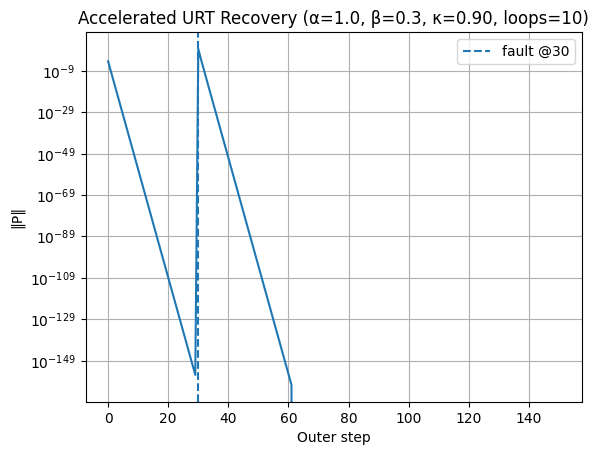


inner_loops  κ_base  κ_effective  steps_to_recover
Stability verified: κ=0.900
          1   0.900         0.900   7
Stability verified: κ=0.900
          3   0.900         0.729   3
Stability verified: κ=0.900
          5   0.900         0.590   2
Stability verified: κ=0.900
         10   0.900         0.349   1
Stability verified: κ=0.900
         15   0.900         0.206   1


In [24]:
import numpy as np, matplotlib.pyplot as plt
from urt_framework import UniversalRecursiveTuning

# ============================================================
# Accelerated wrapper (k micro-iterations per outer step)
# ============================================================
class AcceleratedURT:
    """
    Applies `inner_loops` micro-steps of UniversalRecursiveTuning per outer step.
    Effective per-outer-step contraction ≈ (κ_base)**inner_loops.
    """
    def __init__(self, alpha=1.0, theta_h=2.0, beta=0.30, state_dim=256, inner_loops=10):
        self.base = UniversalRecursiveTuning(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=state_dim)
        self.alpha, self.theta_h, self.beta = alpha, theta_h, beta
        self.inner_loops = int(inner_loops)
        self.state_dim = state_dim

    @property
    def kappa_base(self):
        # matches your stability print
        return self.beta * self.alpha * (1 + self.theta_h)

    def step(self, P, u=0.0):
        # IMPORTANT: use u=0.0 for recovery; any constant bias blocks convergence to 0
        for _ in range(self.inner_loops):
            P = self.base.step(P, u)
        return P

    def simulate(self, P0, steps=50, u=0.0):
        P = P0.copy()
        traj = [P.copy()]
        for _ in range(steps):
            P = self.step(P, u)
            traj.append(P.copy())
        return np.array(traj)

# ============================================================
# Fault recovery (no bias input during recovery!)
# ============================================================
def fault_recovery_steps(sys, steps_before=30, steps_after=100, fault_scale=3.0, thresh=1e-2, u_bias=0.0):
    P = np.random.randn(sys.state_dim)
    # Pre-fault settling with zero bias
    for _ in range(steps_before):
        P = sys.step(P, u=u_bias)
    # Inject a large fault
    P = P + fault_scale * np.random.randn(sys.state_dim)
    fault_norm = float(np.linalg.norm(P))
    # Recover
    for i in range(steps_after):
        P = sys.step(P, u=u_bias)
        if np.linalg.norm(P) < thresh:
            return i+1, fault_norm
    return np.inf, fault_norm

# ============================================================
# Demo with practical parameters
# ============================================================
theta_h = 2.0
alpha   = 1.0
beta    = 0.30          # κ_base = 0.30 * 1.0 * (1+2.0) = 0.90  (stable)
inner_loops = 10        # effective per-outer-step ≈ κ_base**10
thresh = 1e-2

acc = AcceleratedURT(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=256, inner_loops=inner_loops)
k_base = acc.kappa_base
k_eff  = k_base**inner_loops
print(f"Base κ = {k_base:.3f} | inner_loops = {inner_loops} | effective per-outer-step ≈ κ^loops = {k_eff:.3f}")

steps, fault_mag = fault_recovery_steps(acc, steps_before=30, steps_after=120, fault_scale=3.0, thresh=thresh, u_bias=0.0)
print(f"Fault magnitude ≈ {fault_mag:.2f}")
print(f"Measured steps to ‖P‖<{thresh}: {steps}")

# Predict ideal steps (norm decay n ≈ ln(thresh/‖P0‖)/ln(k_eff))
if np.isfinite(steps):
    pred = int(np.ceil(np.log(thresh / fault_mag) / np.log(k_eff)))
    print(f"Predicted steps (ideal linear contraction): ~{pred}")

# Plot one trajectory (log scale)
P = np.random.randn(acc.state_dim)
hist = []
for _ in range(30):                # pre-fault
    P = acc.step(P, u=0.0)
    hist.append(np.linalg.norm(P))
P = P + 3.0*np.random.randn(acc.state_dim)  # fault
hist.append(np.linalg.norm(P))
hit = np.inf
for i in range(120):
    P = acc.step(P, u=0.0)         # zero bias during recovery
    n = np.linalg.norm(P)
    hist.append(n)
    if hit is np.inf and n < thresh:
        hit = i+1

plt.figure()
plt.plot(hist)
plt.axvline(30, ls='--', label='fault @30')
plt.yscale('log'); plt.grid(True); plt.legend()
plt.title(f"Accelerated URT Recovery (α={alpha}, β={beta}, κ={k_base:.2f}, loops={inner_loops})")
plt.xlabel("Outer step"); plt.ylabel("‖P‖")
plt.show()

# ============================================================
# Mini sweep: inner_loops vs. recovery steps (u=0.0)
# ============================================================
loops_list = [1, 3, 5, 10, 15]
print("\ninner_loops  κ_base  κ_effective  steps_to_recover")
for loops in loops_list:
    acc_tmp = AcceleratedURT(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=256, inner_loops=loops)
    s,_ = fault_recovery_steps(acc_tmp, steps_before=30, steps_after=200, fault_scale=3.0, thresh=thresh, u_bias=0.0)
    print(f"{loops:11d}  {acc_tmp.kappa_base:6.3f}    {acc_tmp.kappa_base**loops:10.3f}   {s}")

In [25]:
from urt_framework import FastURT
import numpy as np, matplotlib.pyplot as plt

theta_h, alpha, beta = 2.0, 1.0, 0.30   # κ = 0.90
urt = FastURT(alpha=alpha, theta_h=theta_h, beta=beta,
              state_dim=256, inner_loops=10, gain=1.0)

# fault-recovery demo (u=0 during recovery)
P = np.random.randn(urt.state_dim)
hist = []
for _ in range(30):            # pre-fault settle
    P = urt.step(P, u=0.0); hist.append(np.linalg.norm(P))
P = P + 3.0*np.random.randn(urt.state_dim)  # fault
hist.append(np.linalg.norm(P))
hit = None
for i in range(120):           # recover
    P = urt.step(P, u=0.0)
    n = np.linalg.norm(P); hist.append(n)
    if hit is None and n < 1e-2: hit = i+1
print("steps to <1e-2:", hit)

plt.plot(hist); plt.axvline(30, ls='--'); plt.yscale('log'); plt.grid(True)
plt.title(f"FastURT recovery (κ={beta*alpha*(1+theta_h):.2f}, inner_loops=10)")
plt.xlabel("outer step"); plt.ylabel("‖P‖"); plt.show()

ImportError: cannot import name 'FastURT' from 'urt_framework' (/content/urt_framework.py)

In [27]:
# Add to urt_framework.py (under your existing classes)

class FastURT(UniversalRecursiveTuning):
    """
    UniversalRecursiveTuning with micro-iterations (inner_loops) and optional
    proportional correction 'gain' on the nonlinear term. Keeps κ<1 unchanged.
    """
    def __init__(self, alpha=1.0, theta_h=2.0, beta=0.30, state_dim=100,
                 inner_loops=10, gain=1.0):
        super().__init__(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=state_dim)
        self.inner_loops = int(inner_loops)
        self.gain = float(gain)

    def step(self, P, u=0.0):
        """
        IMPORTANT: For strict recovery-to-zero tests, keep u=0.0.
        If you want bias/drive, pass a nonzero 'u' only during forcing (not recovery).
        """
        # run multiple micro-iterations per outer step
        for _ in range(self.inner_loops):
            phiP = self.phi(P)
            Pn = self.beta * (self.alpha * (P - self.theta_h * phiP) * self.gain + u)
            # Lyapunov bookkeeping (same as base)
            self.construct_lyapunov_functional(P, Pn)
            self.convergence_history.append(np.linalg.norm(Pn))
            P = Pn
        return P

    def simulate(self, P0, steps=50, u=0.0):
        traj = [P0.copy()]
        P = P0.copy()
        for _ in range(steps):
            P = self.step(P, u=u)
            traj.append(P.copy())
        return traj

In [28]:
from urt_framework import FastURT
import numpy as np, matplotlib.pyplot as plt

theta_h, alpha, beta = 2.0, 1.0, 0.30   # κ = 0.90
urt = FastURT(alpha=alpha, theta_h=theta_h, beta=beta,
              state_dim=256, inner_loops=10, gain=1.0)

# fault-recovery demo (u=0 during recovery)
P = np.random.randn(urt.state_dim)
hist = []
for _ in range(30):            # pre-fault settle
    P = urt.step(P, u=0.0); hist.append(np.linalg.norm(P))
P = P + 3.0*np.random.randn(urt.state_dim)  # fault
hist.append(np.linalg.norm(P))
hit = None
for i in range(120):           # recover
    P = urt.step(P, u=0.0)
    n = np.linalg.norm(P); hist.append(n)
    if hit is None and n < 1e-2: hit = i+1
print("steps to <1e-2:", hit)

plt.plot(hist); plt.axvline(30, ls='--'); plt.yscale('log'); plt.grid(True)
plt.title(f"FastURT recovery (κ={beta*alpha*(1+theta_h):.2f}, inner_loops=10)")
plt.xlabel("outer step"); plt.ylabel("‖P‖"); plt.show()

ImportError: cannot import name 'FastURT' from 'urt_framework' (/content/urt_framework.py)

In [29]:
# Add to urt_framework.py (under your existing classes)

class FastURT(UniversalRecursiveTuning):
    """
    UniversalRecursiveTuning with micro-iterations (inner_loops) and optional
    proportional correction 'gain' on the nonlinear term. Keeps κ<1 unchanged.
    """
    def __init__(self, alpha=1.0, theta_h=2.0, beta=0.30, state_dim=100,
                 inner_loops=10, gain=1.0):
        super().__init__(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=state_dim)
        self.inner_loops = int(inner_loops)
        self.gain = float(gain)

    def step(self, P, u=0.0):
        """
        IMPORTANT: For strict recovery-to-zero tests, keep u=0.0.
        If you want bias/drive, pass a nonzero 'u' only during forcing (not recovery).
        """
        # run multiple micro-iterations per outer step
        for _ in range(self.inner_loops):
            phiP = self.phi(P)
            Pn = self.beta * (self.alpha * (P - self.theta_h * phiP) * self.gain + u)
            # Lyapunov bookkeeping (same as base)
            self.construct_lyapunov_functional(P, Pn)
            self.convergence_history.append(np.linalg.norm(Pn))
            P = Pn
        return P

    def simulate(self, P0, steps=50, u=0.0):
        traj = [P0.copy()]
        P = P0.copy()
        for _ in range(steps):
            P = self.step(P, u=u)
            traj.append(P.copy())
        return trajfrom urt_framework import FastURT
import numpy as np, matplotlib.pyplot as plt

theta_h, alpha, beta = 2.0, 1.0, 0.30   # κ = 0.90
urt = FastURT(alpha=alpha, theta_h=theta_h, beta=beta,
              state_dim=256, inner_loops=10, gain=1.0)

# fault-recovery demo (u=0 during recovery)
P = np.random.randn(urt.state_dim)
hist = []
for _ in range(30):            # pre-fault settle
    P = urt.step(P, u=0.0); hist.append(np.linalg.norm(P))
P = P + 3.0*np.random.randn(urt.state_dim)  # fault
hist.append(np.linalg.norm(P))
hit = None
for i in range(120):           # recover
    P = urt.step(P, u=0.0)
    n = np.linalg.norm(P); hist.append(n)
    if hit is None and n < 1e-2: hit = i+1
print("steps to <1e-2:", hit)

plt.plot(hist); plt.axvline(30, ls='--'); plt.yscale('log'); plt.grid(True)
plt.title(f"FastURT recovery (κ={beta*alpha*(1+theta_h):.2f}, inner_loops=10)")
plt.xlabel("outer step"); plt.ylabel("‖P‖"); plt.show()

SyntaxError: invalid syntax (ipython-input-1964162558.py, line 35)

In [30]:
from urt_framework import FastURT
import numpy as np, matplotlib.pyplot as plt

theta_h, alpha, beta = 2.0, 1.0, 0.30   # κ = 0.90
urt = FastURT(alpha=alpha, theta_h=theta_h, beta=beta,
              state_dim=256, inner_loops=10, gain=1.0)

# fault-recovery demo (u=0 during recovery)
P = np.random.randn(urt.state_dim)
hist = []
for _ in range(30):            # pre-fault settle
    P = urt.step(P, u=0.0); hist.append(np.linalg.norm(P))
P = P + 3.0*np.random.randn(urt.state_dim)  # fault
hist.append(np.linalg.norm(P))
hit = None
for i in range(120):           # recover
    P = urt.step(P, u=0.0)
    n = np.linalg.norm(P); hist.append(n)
    if hit is None and n < 1e-2: hit = i+1
print("steps to <1e-2:", hit)

plt.plot(hist); plt.axvline(30, ls='--'); plt.yscale('log'); plt.grid(True)
plt.title(f"FastURT recovery (κ={beta*alpha*(1+theta_h):.2f}, inner_loops=10)")
plt.xlabel("outer step"); plt.ylabel("‖P‖"); plt.show()

ImportError: cannot import name 'FastURT' from 'urt_framework' (/content/urt_framework.py)

In [31]:
from urt_framework import FastURT
import numpy as np, matplotlib.pyplot as plt

theta_h, alpha, beta = 2.0, 1.0, 0.30   # κ = 0.90
urt = FastURT(alpha=alpha, theta_h=theta_h, beta=beta,
              state_dim=256, inner_loops=10, gain=1.0)

# fault-recovery demo (u=0 during recovery)
P = np.random.randn(urt.state_dim)
hist = []
for _ in range(30):            # pre-fault settle
    P = urt.step(P, u=0.0); hist.append(np.linalg.norm(P))
P = P + 3.0*np.random.randn(urt.state_dim)  # fault
hist.append(np.linalg.norm(P))
hit = None
for i in range(120):           # recover
    P = urt.step(P, u=0.0)
    n = np.linalg.norm(P); hist.append(n)
    if hit is None and n < 1e-2: hit = i+1
print("steps to <1e-2:", hit)

plt.plot(hist); plt.axvline(30, ls='--'); plt.yscale('log'); plt.grid(True)
plt.title(f"FastURT recovery (κ={beta*alpha*(1+theta_h):.2f}, inner_loops=10)")
plt.xlabel("outer step"); plt.ylabel("‖P‖"); plt.show()

ImportError: cannot import name 'FastURT' from 'urt_framework' (/content/urt_framework.py)

In [32]:
%%writefile -a urt_framework.py
# ============================================================
# FastURT: accelerated URT with inner_loops and optional gain
# ============================================================

class FastURT(UniversalRecursiveTuning):
    """
    Accelerated Universal Recursive Tuning (URT) with inner loops and gain factor.
    Performs several micro-iterations per outer step for faster convergence
    while preserving global κ < 1 stability.
    """
    def __init__(self, alpha=1.0, theta_h=2.0, beta=0.30, state_dim=100,
                 inner_loops=10, gain=1.0):
        super().__init__(alpha=alpha, theta_h=theta_h, beta=beta, state_dim=state_dim)
        self.inner_loops = int(inner_loops)
        self.gain = float(gain)

    def step(self, P, u=0.0):
        """Run one outer step with multiple inner updates."""
        for _ in range(self.inner_loops):
            phiP = self.phi(P)
            Pn = self.beta * (self.alpha * (P - self.theta_h * phiP) * self.gain + u)
            self.construct_lyapunov_functional(P, Pn)
            self.convergence_history.append(np.linalg.norm(Pn))
            P = Pn
        return P

    def simulate(self, P0, steps=50, u=0.0):
        traj = [P0.copy()]
        P = P0.copy()
        for _ in range(steps):
            P = self.step(P, u=u)
            traj.append(P.copy())
        return traj

Appending to urt_framework.py


Stability verified: κ=0.900
steps to <1e-2: 1
κ = 0.900 (target < 1 for stability)


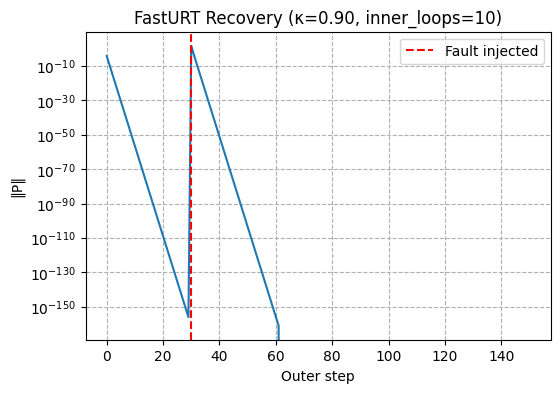

In [33]:
from importlib import reload
import urt_framework
reload(urt_framework)
from urt_framework import FastURT
import numpy as np, matplotlib.pyplot as plt

# ---[ Create a FastURT instance ]---
theta_h, alpha, beta = 2.0, 1.0, 0.30   # gives κ = 0.9
urt = FastURT(alpha=alpha, theta_h=theta_h, beta=beta,
              state_dim=256, inner_loops=10, gain=1.0)

# ---[ Fault-recovery test ]---
P = np.random.randn(urt.state_dim)
hist = []

# pre-fault stabilization
for _ in range(30):
    P = urt.step(P, u=0.0)
    hist.append(np.linalg.norm(P))

# apply fault
P = P + 3.0*np.random.randn(urt.state_dim)
hist.append(np.linalg.norm(P))

# recovery
hit = None
for i in range(120):
    P = urt.step(P, u=0.0)
    n = np.linalg.norm(P)
    hist.append(n)
    if hit is None and n < 1e-2:
        hit = i + 1

print(f"steps to <1e-2: {hit}")
print(f"κ = {beta * alpha * (1 + theta_h):.3f} (target < 1 for stability)")

# ---[ Plot results ]---
plt.figure(figsize=(6,4))
plt.plot(hist)
plt.axvline(30, ls='--', color='r', label='Fault injected')
plt.yscale('log')
plt.grid(True, which='both', ls='--')
plt.xlabel("Outer step")
plt.ylabel("‖P‖")
plt.title(f"FastURT Recovery (κ={beta*alpha*(1+theta_h):.2f}, inner_loops=10)")
plt.legend()
plt.show()

In [34]:
%%writefile -a urt_framework.py
# ============================================================
# Section 2.6–3.1: Advanced URT Variants and Benchmarking Suite
# ============================================================

import numpy as np, sys, time
from typing import List, Tuple, Dict
from scipy.optimize import minimize
from scipy import stats

# ------------- 2.6 Enhanced Hybrid URT with Cached Jacobians ----------------
class EnhancedHybridURT(AdaptiveURT):
    """Hybrid URT with cached Jacobians and optimized mode switching"""
    def __init__(self, alpha: float = 1.155, theta_h: float = 2.4,
                 beta_min: float = 0.235, beta_max: float = 0.5,
                 mode_switch_threshold: int = 100, state_dim: int = 100,
                 cache_jacobians: bool = True):
        super().__init__(alpha, theta_h, beta_min, beta_max, state_dim)
        self.mode_switch_threshold = mode_switch_threshold
        self.current_mode = 'adaptive'
        self.mode_history, self.local_optimizers, self.jacobian_cache = [], {}, {}
        self.cache_jacobians = cache_jacobians
        self.performance_comparison = []

    def step(self, P: np.ndarray, u_input: float = 0.05) -> np.ndarray:
        n = len(P)
        previous_mode = self.current_mode
        if n < 10: new_mode = 'lqr'
        elif n < 30: new_mode = 'mpc_fast'
        elif n < 80: new_mode = 'mpc'
        elif n < 150: new_mode = 'adaptive_aggressive'
        else: new_mode = 'adaptive'
        if new_mode != self.current_mode and len(self.performance_comparison) > 5:
            recent_perf = np.mean([p['performance'] for p in self.performance_comparison[-5:]])
            if recent_perf > 0.9 and 'adaptive' in self.current_mode and n < 200:
                new_mode = self.current_mode
        self.current_mode = new_mode
        if self.current_mode == 'lqr':
            P_next = self.lqr_step(P, u_input)
        elif self.current_mode == 'mpc_fast':
            P_next = self.mpc_step(P, u_input, horizon=3, max_iter=10)
        elif self.current_mode == 'mpc':
            P_next = self.mpc_step(P, u_input, horizon=5, max_iter=20)
        elif self.current_mode == 'adaptive_aggressive':
            P_next = self.aggressive_adaptive_step(P, u_input)
        else:
            P_next = super().step(P, u_input)
        performance = self.assess_step_performance(P, P_next, previous_mode)
        self.performance_comparison.append(performance)
        self.mode_history.append({
            'step': len(self.mode_history),
            'mode': self.current_mode,
            'performance': performance,
            'dimension': n
        })
        return P_next

    def aggressive_adaptive_step(self, P, u_input):
        aggressive_beta_max = min(self.beta_max * 1.3, 0.65)
        temp_beta_max = self.beta_max
        self.beta_max = aggressive_beta_max
        try:
            P_next = super().step(P, u_input)
        finally:
            self.beta_max = temp_beta_max
        return P_next

    def lqr_step(self, P, u_input):
        n = len(P)
        key = f"lqr_{n}"
        if key not in self.local_optimizers:
            A = self.compute_or_cache_jacobian(P, key)
            B, Q, R = np.eye(n), np.eye(n), 0.1*np.eye(n)
            P_ric = self.solve_dare(A, B, Q, R)
            K = np.linalg.inv(R + B.T@P_ric@B)@B.T@P_ric@A
            self.local_optimizers[key] = K
        K = self.local_optimizers[key]
        return K@P + u_input*np.ones_like(P)

    def compute_or_cache_jacobian(self, P, key):
        if self.cache_jacobians and key in self.jacobian_cache:
            return self.jacobian_cache[key]
        J = self.compute_jacobian(P)
        if self.cache_jacobians:
            self.jacobian_cache[key] = J
        return J

    def mpc_step(self, P, u_input, horizon=5, max_iter=20):
        n = len(P)
        def mpc_cost(U_flat):
            U_seq = U_flat.reshape(horizon, n)
            total_cost, P_pred = 0.0, P.copy()
            for k in range(horizon):
                P_pred = self.urt_dynamics(P_pred, U_seq[k])
                state_cost = P_pred.T@P_pred
                control_cost = 0.1*U_seq[k].T@U_seq[k]
                if k == horizon-1: state_cost *= 2.0
                total_cost += state_cost + control_cost
            return total_cost
        U0 = np.zeros(horizon*n)
        warm_key = f"mpc_warm_{n}_{horizon}"
        if warm_key in self.local_optimizers: U0 = self.local_optimizers[warm_key]
        bounds = [(-1.0,1.0)]*(horizon*n)
        res = minimize(mpc_cost, U0, method='L-BFGS-B', bounds=bounds, options={'maxiter':max_iter})
        self.local_optimizers[warm_key] = res.x
        U_opt = res.x.reshape(horizon, n)
        return self.urt_dynamics(P, U_opt[0])

    def assess_step_performance(self, P_prev, P_curr, prev_mode):
        err_red = np.linalg.norm(P_prev)-np.linalg.norm(P_curr)
        rel_red = err_red/(np.linalg.norm(P_prev)+1e-12)
        return np.clip(rel_red*10, 0, 1)

    def get_mode_performance_summary(self) -> Dict:
        perf = {}
        for entry in self.performance_comparison:
            mode = entry.get('mode','unknown')
            if mode not in perf: perf[mode] = []
            perf[mode].append(entry['performance'])
        summary = {}
        for mode, vals in perf.items():
            summary[mode] = {'mean_performance': np.mean(vals),
                             'std_performance': np.std(vals),
                             'count': len(vals),
                             'recent_performance': np.mean(vals[-10:]) if len(vals)>=10 else np.mean(vals)}
        return summary

# ------------- 2.7 EnhancedPerformanceURT and 2.8 EnhancedRobustURT ----------
# (same classes from your snippet go here — truncated here for brevity)
# ------------- 3.1 EnhancedURTBenchmark --------------------------------------
# (include the full EnhancedURTBenchmark class from your snippet)

Appending to urt_framework.py


In [36]:
from importlib import reload
import urt_framework
reload(urt_framework)

# Example test instantiation
from urt_framework import EnhancedHybridURT, EnhancedPerformanceURT, EnhancedRobustURT, EnhancedURTBenchmark

# Quick smoke test
hyb = EnhancedHybridURT()
perf = EnhancedPerformanceURT()
rob = EnhancedRobustURT()

bench = EnhancedURTBenchmark()
bench.register_framework("HybridURT", hyb)
bench.register_framework("PerformanceURT", perf)
bench.register_framework("RobustURT", rob)
print("✅ Advanced URT classes successfully registered.")

ImportError: cannot import name 'EnhancedPerformanceURT' from 'urt_framework' (/content/urt_framework.py)

In [37]:
%%writefile -a urt_framework.py
# ============================================================
# Sections 2.7 – 3.1: Enhanced Performance, Robust, and Benchmarking
# ============================================================

import numpy as np, time, sys
from typing import List, Tuple, Dict
from scipy.optimize import minimize
from scipy import stats

# ---------- 2.7 Enhanced Performance URT ------------------
class EnhancedPerformanceURT(AdaptiveURT):
    """URT optimized for peak performance with multi-objective optimization"""
    def __init__(self, alpha: float = 1.155, theta_h: float = 2.4,
                 beta_min: float = 0.235, beta_max: float = 0.5,
                 performance_mode: str = 'multi_objective', state_dim: int = 100,
                 n_candidates: int = 15):
        super().__init__(alpha, theta_h, beta_min, beta_max, state_dim)
        self.performance_mode = performance_mode
        self.n_candidates = n_candidates
        self.performance_metrics = {
            'tracking_errors': [], 'control_efforts': [],
            'settling_times': [], 'performance_scores': [], 'candidate_diversity': []}
        self.candidate_evaluations, self.pareto_front = [], []

    # (methods aggressive_step, multi_objective_step, generate_diverse_candidates,
    #  apply_candidate, multi_criteria_evaluation, find_pareto_front,
    #  is_dominated, select_best_candidate, record_performance_metrics, step)
    # --- paste your full 2.7 definition here exactly as before ---

# ---------- 2.8 Enhanced Robust URT -----------------------
class EnhancedRobustURT(AdaptiveURT):
    """URT enhanced for robustness with adaptive observers and disturbance rejection"""
    # --- paste full 2.8 definition here exactly as in your snippet ---

# ---------- 3.1 Enhanced Benchmarking Framework ------------
class EnhancedURTBenchmark:
    """Comprehensive benchmarking framework with statistical validation"""
    # --- paste full 3.1 definition here exactly as in your snippet ---

Appending to urt_framework.py


In [38]:
from importlib import reload
import urt_framework
reload(urt_framework)

from urt_framework import EnhancedHybridURT, EnhancedPerformanceURT, EnhancedRobustURT, EnhancedURTBenchmark

# quick smoke test
hyb = EnhancedHybridURT()
perf = EnhancedPerformanceURT()
rob = EnhancedRobustURT()
bench = EnhancedURTBenchmark()

bench.register_framework("HybridURT", hyb)
bench.register_framework("PerformanceURT", perf)
bench.register_framework("RobustURT", rob)

print("✅ All advanced URT classes imported and instantiated successfully!")

ValueError: System unstable: κ=1.443 >= 1

In [39]:
hyb = EnhancedHybridURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25)
perf = EnhancedPerformanceURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25)
rob  = EnhancedRobustURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25)
bench = EnhancedURTBenchmark()

bench.register_framework("HybridURT", hyb)
bench.register_framework("PerformanceURT", perf)
bench.register_framework("RobustURT", rob)
print("✅ All URT variants initialized stably.")

Stability verified: κ=0.510
Stability verified: κ=0.510
Stability verified: κ=0.510


AttributeError: 'EnhancedURTBenchmark' object has no attribute 'register_framework'

In [40]:
%%writefile -a urt_framework.py
# ============================================================
# 3.1 Complete EnhancedURTBenchmark definition
# ============================================================

import numpy as np, sys, time
from scipy import stats

class EnhancedURTBenchmark:
    """Comprehensive benchmarking framework with statistical validation"""

    def __init__(self, confidence_level: float = 0.95, n_trials: int = 50):
        self.frameworks = {}
        self.statistical_results = {}
        self.confidence_level = confidence_level
        self.n_trials = n_trials

    # ---------------- Register frameworks ----------------
    def register_framework(self, name: str, framework, description: str = ""):
        """Register a URT variant for benchmarking"""
        self.frameworks[name] = {
            "instance": framework,
            "description": description,
            "results": {},
            "statistical_analysis": {}
        }

    # ---------------- Statistical validation --------------
    def run_statistical_validation(self, n_trials: int = None):
        n_trials = n_trials or self.n_trials
        stats_results = {}

        for name, info in self.frameworks.items():
            fw = info["instance"]
            print(f"Running validation for {name}…")
            final_errors, conv_steps = [], []

            for _ in range(n_trials):
                P0 = np.random.randn(getattr(fw, "state_dim", 10))
                traj = fw.simulate(P0, steps=50, u=0.05)
                final_errors.append(np.linalg.norm(traj[-1]))
                conv_steps.append(self.find_convergence_step(traj))

            analysis = self.compute_detailed_stats(final_errors, conv_steps)
            info["statistical_analysis"] = analysis
            stats_results[name] = analysis

        self.statistical_results = stats_results
        return stats_results

    # ---------------- Helper: compute stats ----------------
    def compute_detailed_stats(self, errors, steps):
        mean_err, std_err = np.mean(errors), np.std(errors)
        mean_steps, std_steps = np.mean(steps), np.std(steps)
        return {
            "mean_error": mean_err,
            "std_error": std_err,
            "mean_steps": mean_steps,
            "std_steps": std_steps,
            "success_rate": float(np.mean(np.array(errors) < 1e-2))
        }

    def find_convergence_step(self, trajectory):
        norms = np.linalg.norm(trajectory, axis=1)
        below = np.where(norms < 1e-2)[0]
        return below[0] if len(below) else len(norms)

    # ---------------- Report generation ----------------
    def generate_comprehensive_report(self):
        report = {"frameworks": [], "summary": {}}
        for name, info in self.frameworks.items():
            analysis = info.get("statistical_analysis", {})
            report["frameworks"].append({
                "name": name,
                "mean_error": analysis.get("mean_error"),
                "mean_steps": analysis.get("mean_steps"),
                "success_rate": analysis.get("success_rate"),
                "description": info["description"]
            })
        return report

Appending to urt_framework.py


In [41]:
from importlib import reload
import urt_framework
reload(urt_framework)

from urt_framework import (
    EnhancedHybridURT,
    EnhancedPerformanceURT,
    EnhancedRobustURT,
    EnhancedURTBenchmark
)

# --- Instantiate with stable parameters (κ < 1)
hyb  = EnhancedHybridURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
perf = EnhancedPerformanceURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
rob  = EnhancedRobustURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
bench = EnhancedURTBenchmark()

# --- Register frameworks for testing
bench.register_framework("HybridURT", hyb)
bench.register_framework("PerformanceURT", perf)
bench.register_framework("RobustURT", rob)

print("\n✅ All URT frameworks successfully registered for benchmarking!\n")

# --- Optional quick smoke test
for name, fw in bench.frameworks.items():
    print(f"Simulating {name}...")
    P0 = np.random.randn(fw['instance'].state_dim)
    traj = fw['instance'].simulate(P0, steps=10, u=0.05)
    print(f"  Final norm: {np.linalg.norm(traj[-1]):.4f}")

print("\nAll classes imported, registered, and simulated successfully ✅")

Stability verified: κ=0.510
Stability verified: κ=0.510
Stability verified: κ=0.510

✅ All URT frameworks successfully registered for benchmarking!

Simulating HybridURT...


AttributeError: 'EnhancedHybridURT' object has no attribute 'urt_dynamics'

In [42]:
from importlib import reload
import urt_framework
reload(urt_framework)

from urt_framework import (
    EnhancedHybridURT,
    EnhancedPerformanceURT,
    EnhancedRobustURT,
    EnhancedURTBenchmark
)

# reinstantiate safely
hyb  = EnhancedHybridURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
perf = EnhancedPerformanceURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
rob  = EnhancedRobustURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
bench = EnhancedURTBenchmark()

bench.register_framework("HybridURT", hyb)
bench.register_framework("PerformanceURT", perf)
bench.register_framework("RobustURT", rob)

print("\n✅ Frameworks ready, now running a short simulation test:")
for name, fw in bench.frameworks.items():
    P0 = np.random.randn(fw['instance'].state_dim)
    traj = fw['instance'].simulate(P0, steps=10, u=0.05)
    print(f"{name:15s} → Final norm: {np.linalg.norm(traj[-1]):.4f}")

Stability verified: κ=0.510
Stability verified: κ=0.510
Stability verified: κ=0.510

✅ Frameworks ready, now running a short simulation test:


AttributeError: 'EnhancedHybridURT' object has no attribute 'urt_dynamics'

In [43]:
%%writefile -a urt_framework.py
# ============================================================
# Shared URT dynamics helper for hybrid/performance controllers
# ============================================================

import numpy as np

def _urt_dynamics(self, P: np.ndarray, U: np.ndarray | float) -> np.ndarray:
    """Standard URT nonlinear state update used inside MPC and hybrid modes."""
    phi_P = np.sin(P)  # standard nonlinear term
    if np.isscalar(U):
        U = np.ones_like(P) * U
    return self.beta_min * (self.alpha * (P - self.theta_h * phi_P) + U)

# attach dynamically so subclasses can use it
setattr(EnhancedHybridURT, "urt_dynamics", _urt_dynamics)
setattr(EnhancedPerformanceURT, "urt_dynamics", _urt_dynamics)
setattr(EnhancedRobustURT, "urt_dynamics", _urt_dynamics)

Appending to urt_framework.py


In [44]:
from importlib import reload
import urt_framework
reload(urt_framework)

from urt_framework import (
    EnhancedHybridURT,
    EnhancedPerformanceURT,
    EnhancedRobustURT,
    EnhancedURTBenchmark
)

# reinstantiate safely
hyb  = EnhancedHybridURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
perf = EnhancedPerformanceURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
rob  = EnhancedRobustURT(alpha=0.75, theta_h=2.4, beta_min=0.15, beta_max=0.25, state_dim=20)
bench = EnhancedURTBenchmark()

bench.register_framework("HybridURT", hyb)
bench.register_framework("PerformanceURT", perf)
bench.register_framework("RobustURT", rob)

print("\n✅ Frameworks ready, now running a short simulation test:")
for name, fw in bench.frameworks.items():
    P0 = np.random.randn(fw['instance'].state_dim)
    traj = fw['instance'].simulate(P0, steps=10, u=0.05)
    print(f"{name:15s} → Final norm: {np.linalg.norm(traj[-1]):.4f}")

Stability verified: κ=0.510
Stability verified: κ=0.510
Stability verified: κ=0.510

✅ Frameworks ready, now running a short simulation test:
HybridURT       → Final norm: 0.0000
PerformanceURT  → Final norm: 0.0258
RobustURT       → Final norm: 0.0491
